# Data Exploration and Visualization

##  initial descriptive analysis for the dataset

### Load dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set styles
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load dataset
df = pd.read_csv("/content/sample_data/healthcare-dataset-stroke-data (2).csv")

df.drop('id', axis=1, inplace=True)
# Display first few rows
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### info about dataset

In [2]:
# Info and data types
df.info()

# Check for missing values
df.isnull().sum()

# Basic statistics
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


## Data visualization

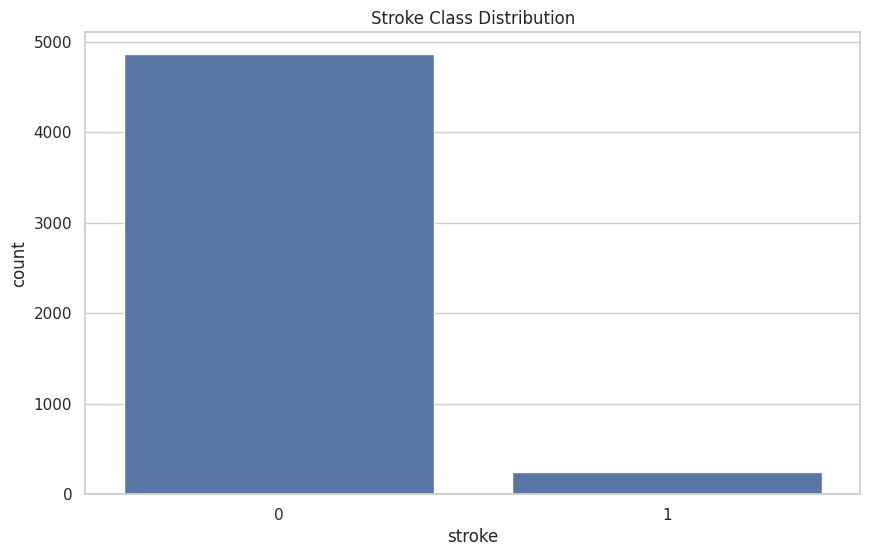

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [3]:
# Check target distribution
sns.countplot(data=df, x="stroke")
plt.title("Stroke Class Distribution")
plt.show()

# Percentage of stroke cases
stroke_percent = df['stroke'].value_counts(normalize=True) * 100
print(stroke_percent)


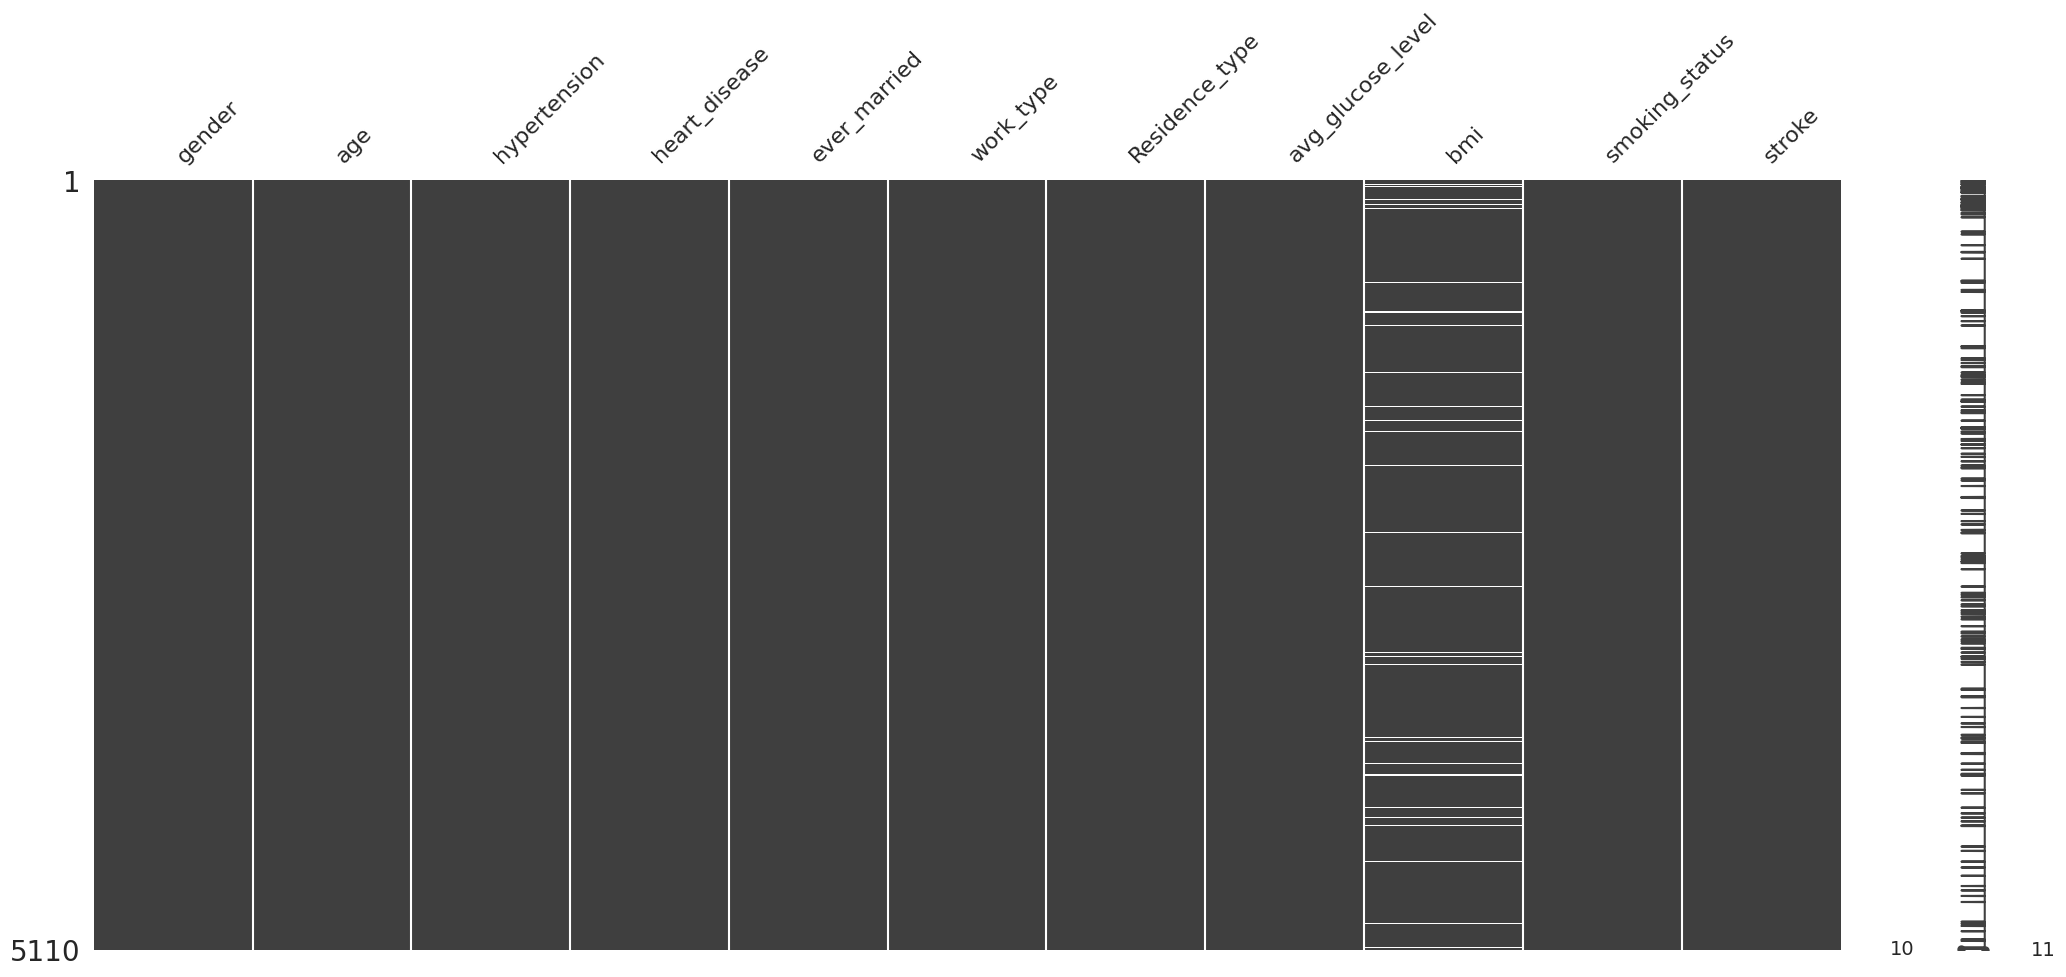

In [4]:
import missingno as msno

# Visualize missing data
msno.matrix(df)
plt.show()


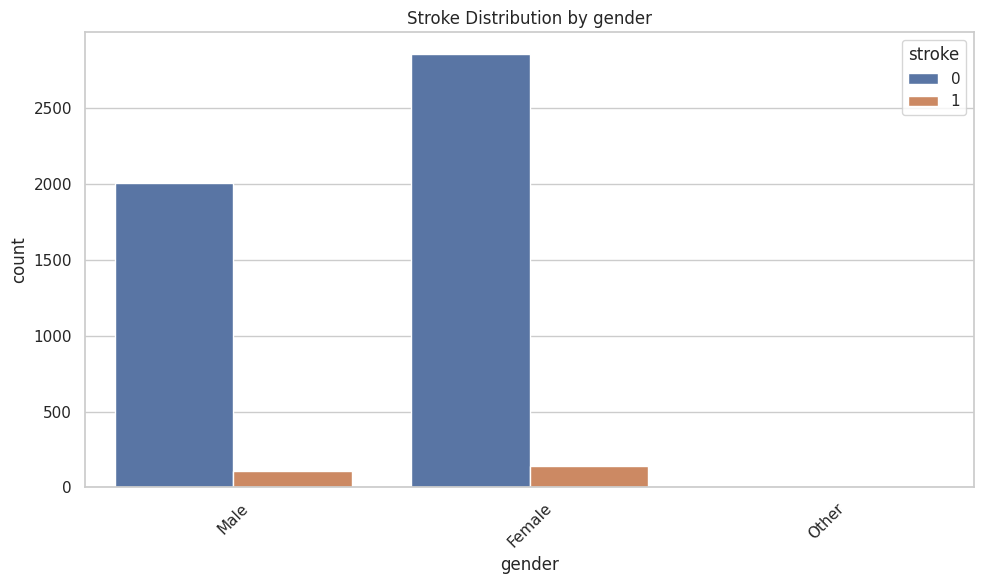

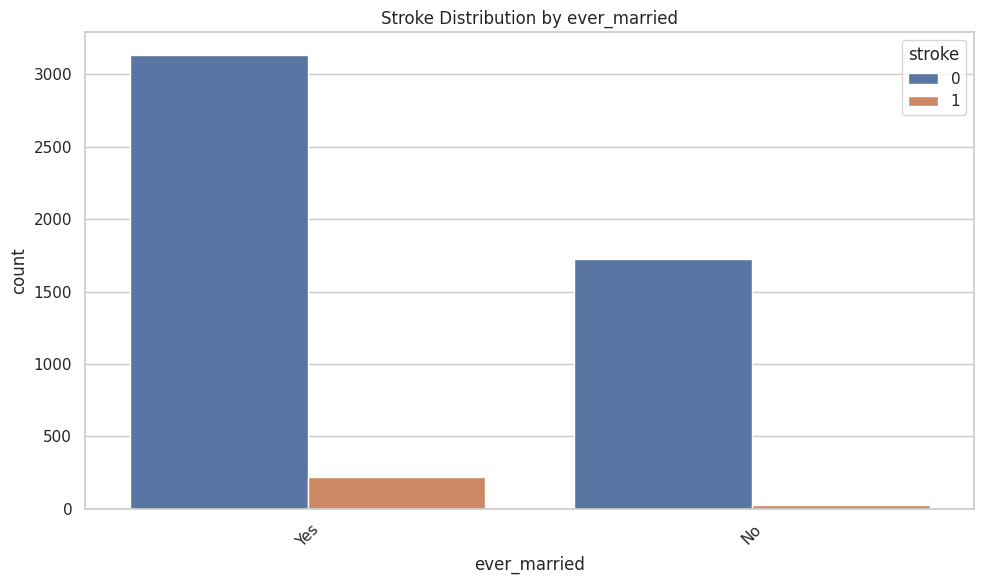

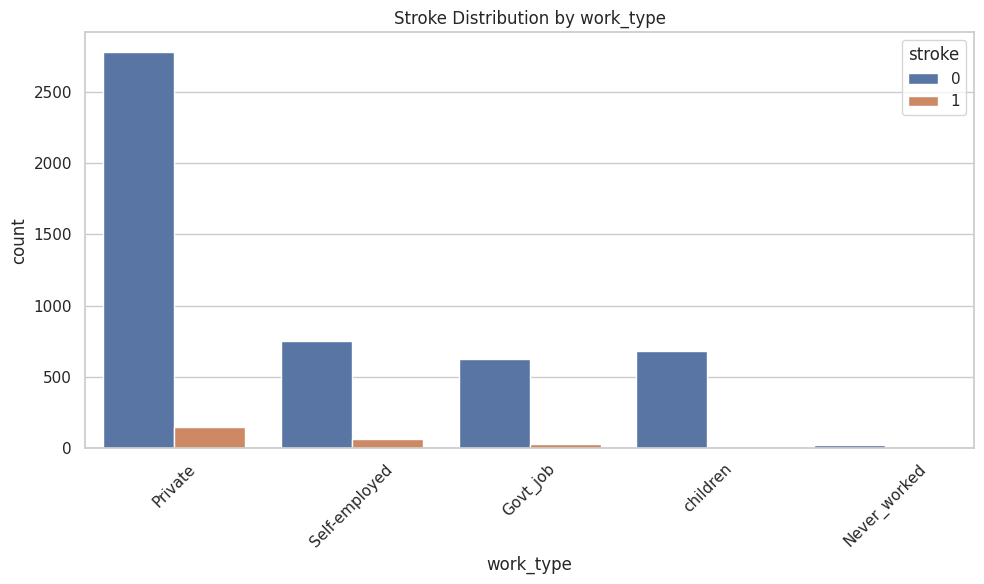

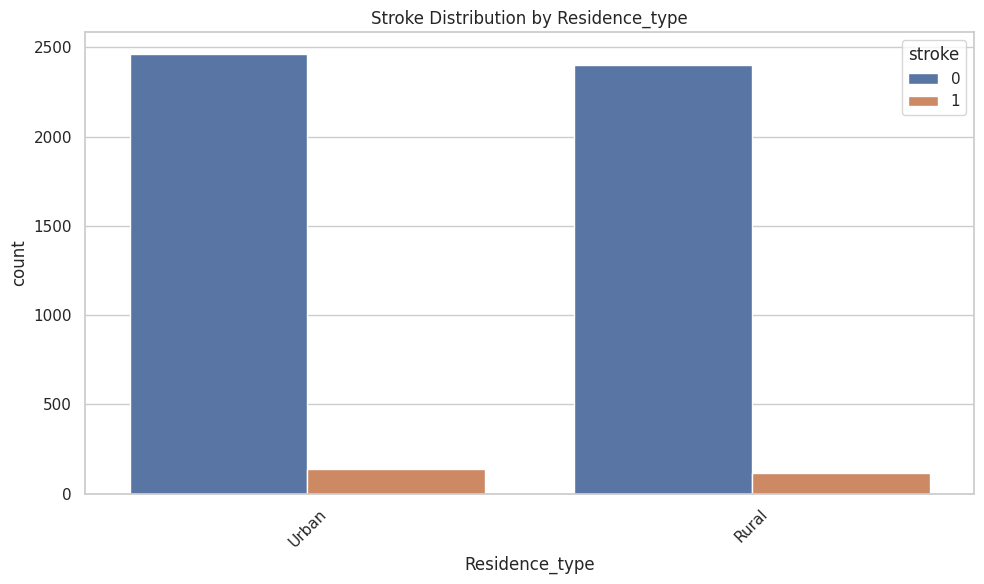

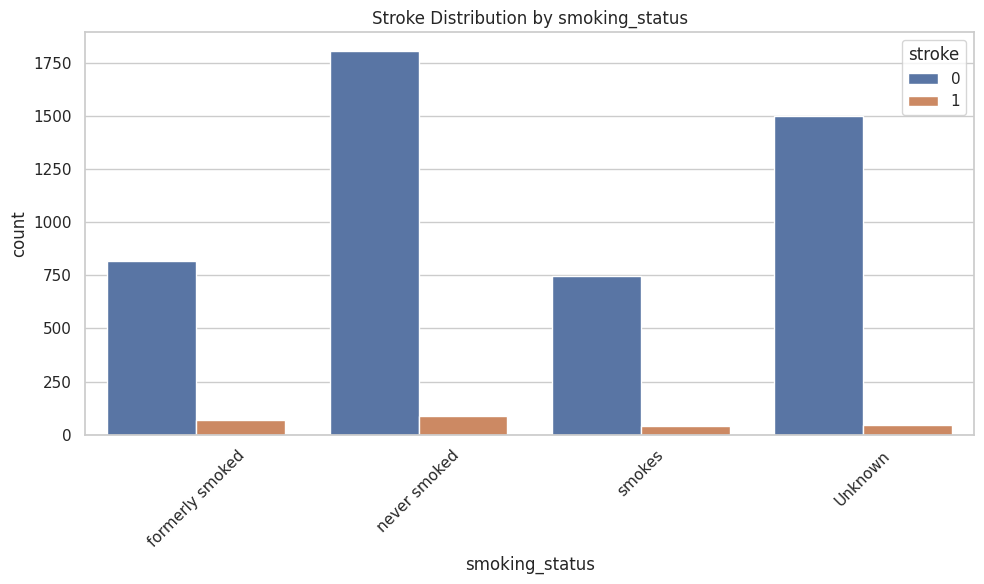

In [5]:
cat_features = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

for col in cat_features:
    sns.countplot(data=df, x=col, hue="stroke")
    plt.title(f"Stroke Distribution by {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


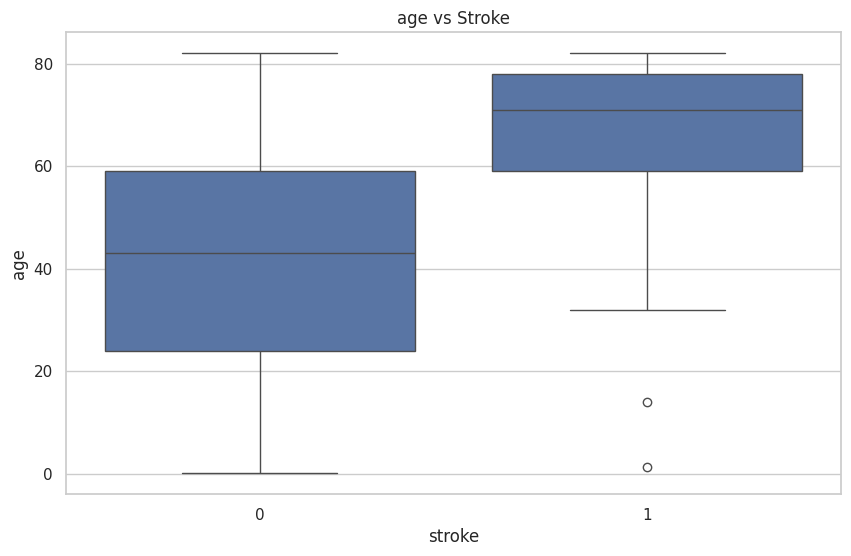

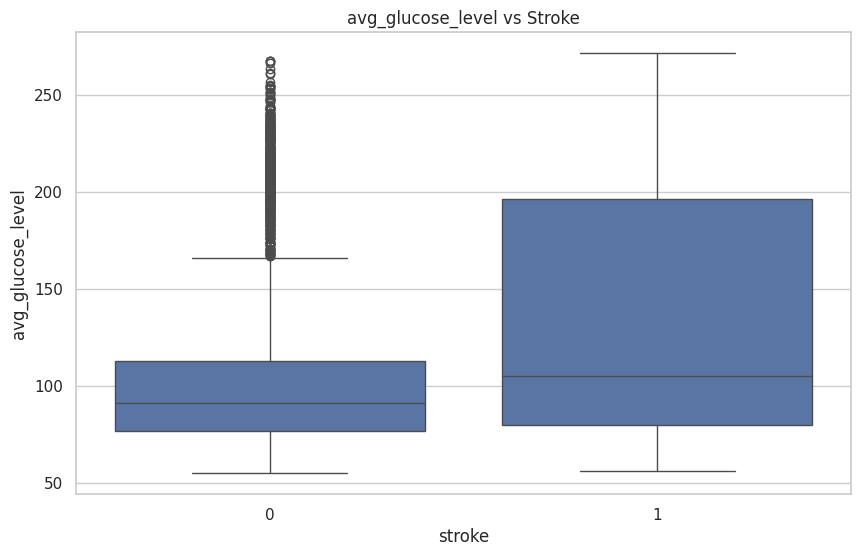

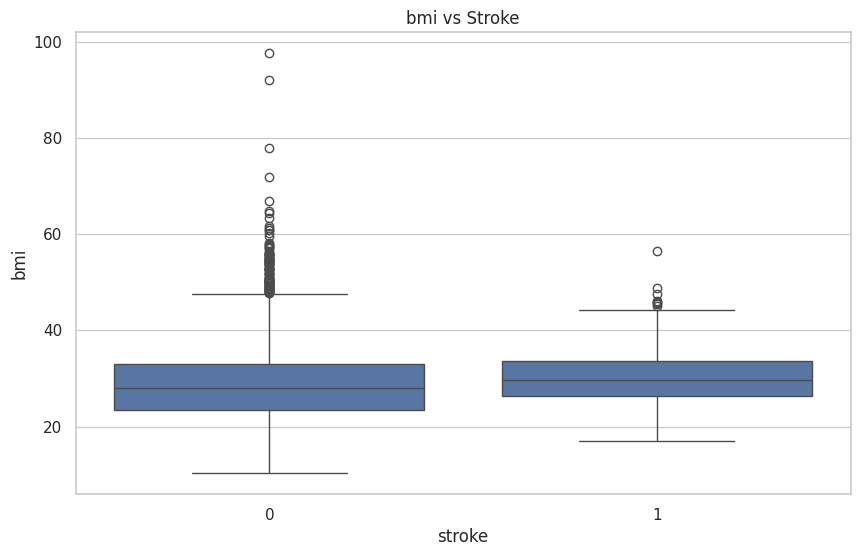

In [6]:
num_features = ["age", "avg_glucose_level", "bmi"]

for col in num_features:
    sns.boxplot(data=df, x="stroke", y=col)
    plt.title(f"{col} vs Stroke")
    plt.show()


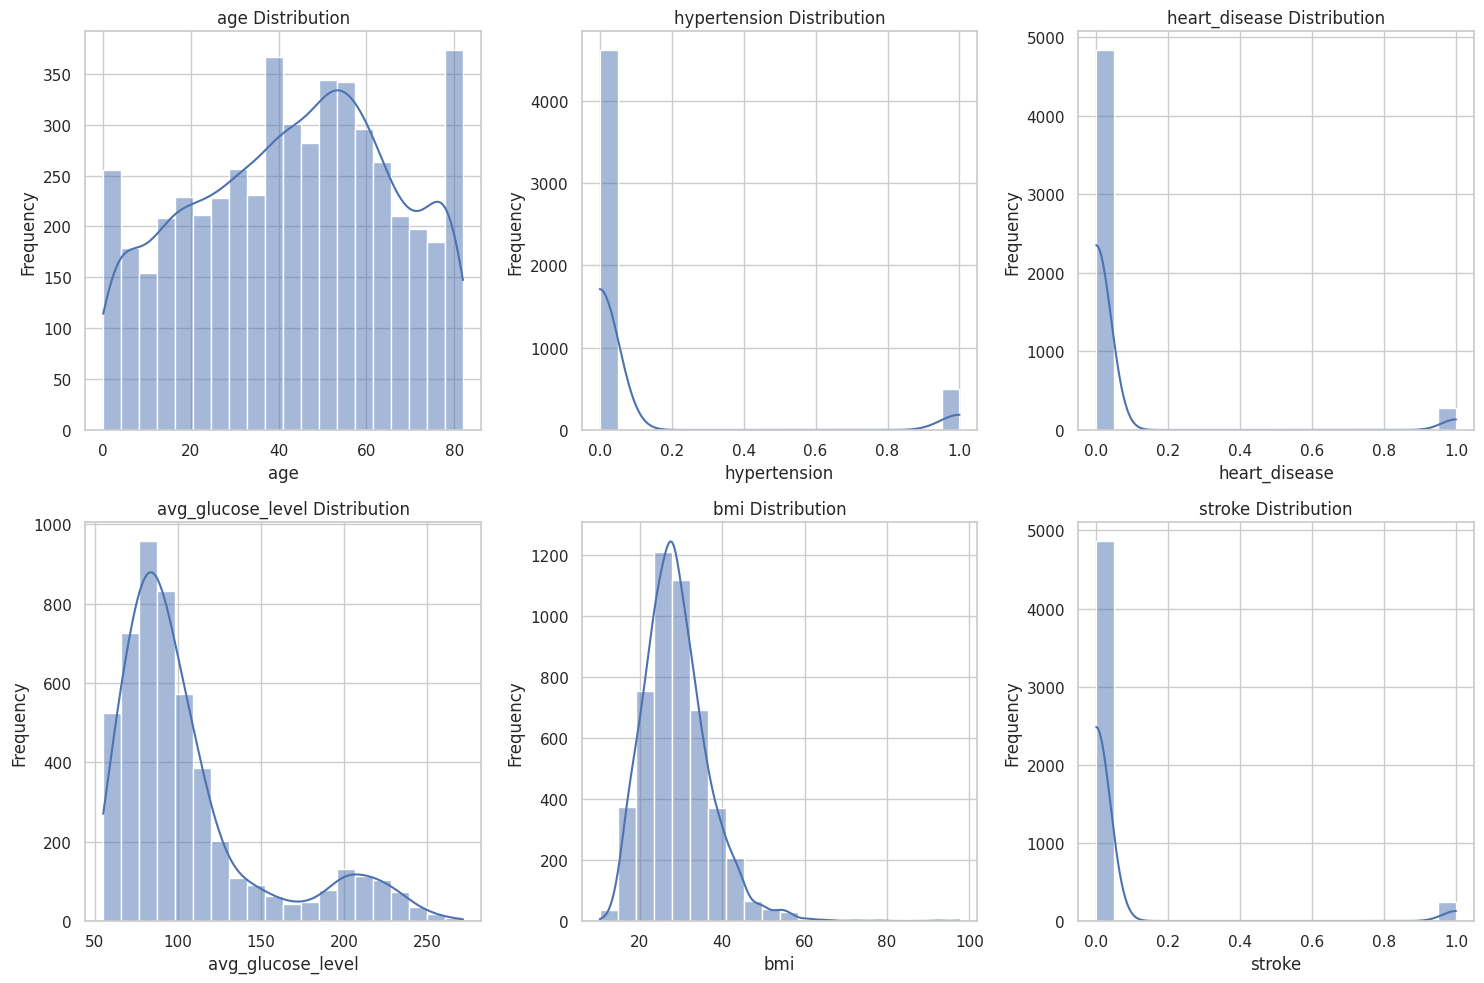

In [7]:
numeric_features = df.select_dtypes(include=['int', 'float']).columns

fig, axes = plt.subplots(nrows=(len(numeric_features) + 2) // 3, ncols=3, figsize=(15, 5 * ((len(numeric_features) + 2) // 3)))
axes = axes.flatten()
for ax, feature in zip(axes, numeric_features):
    sns.histplot(df[feature], bins=20, kde=True, ax=ax)
    ax.set_title(f'{feature} Distribution')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')

for i in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[i])
plt.tight_layout()
plt.show()

### scatter plots

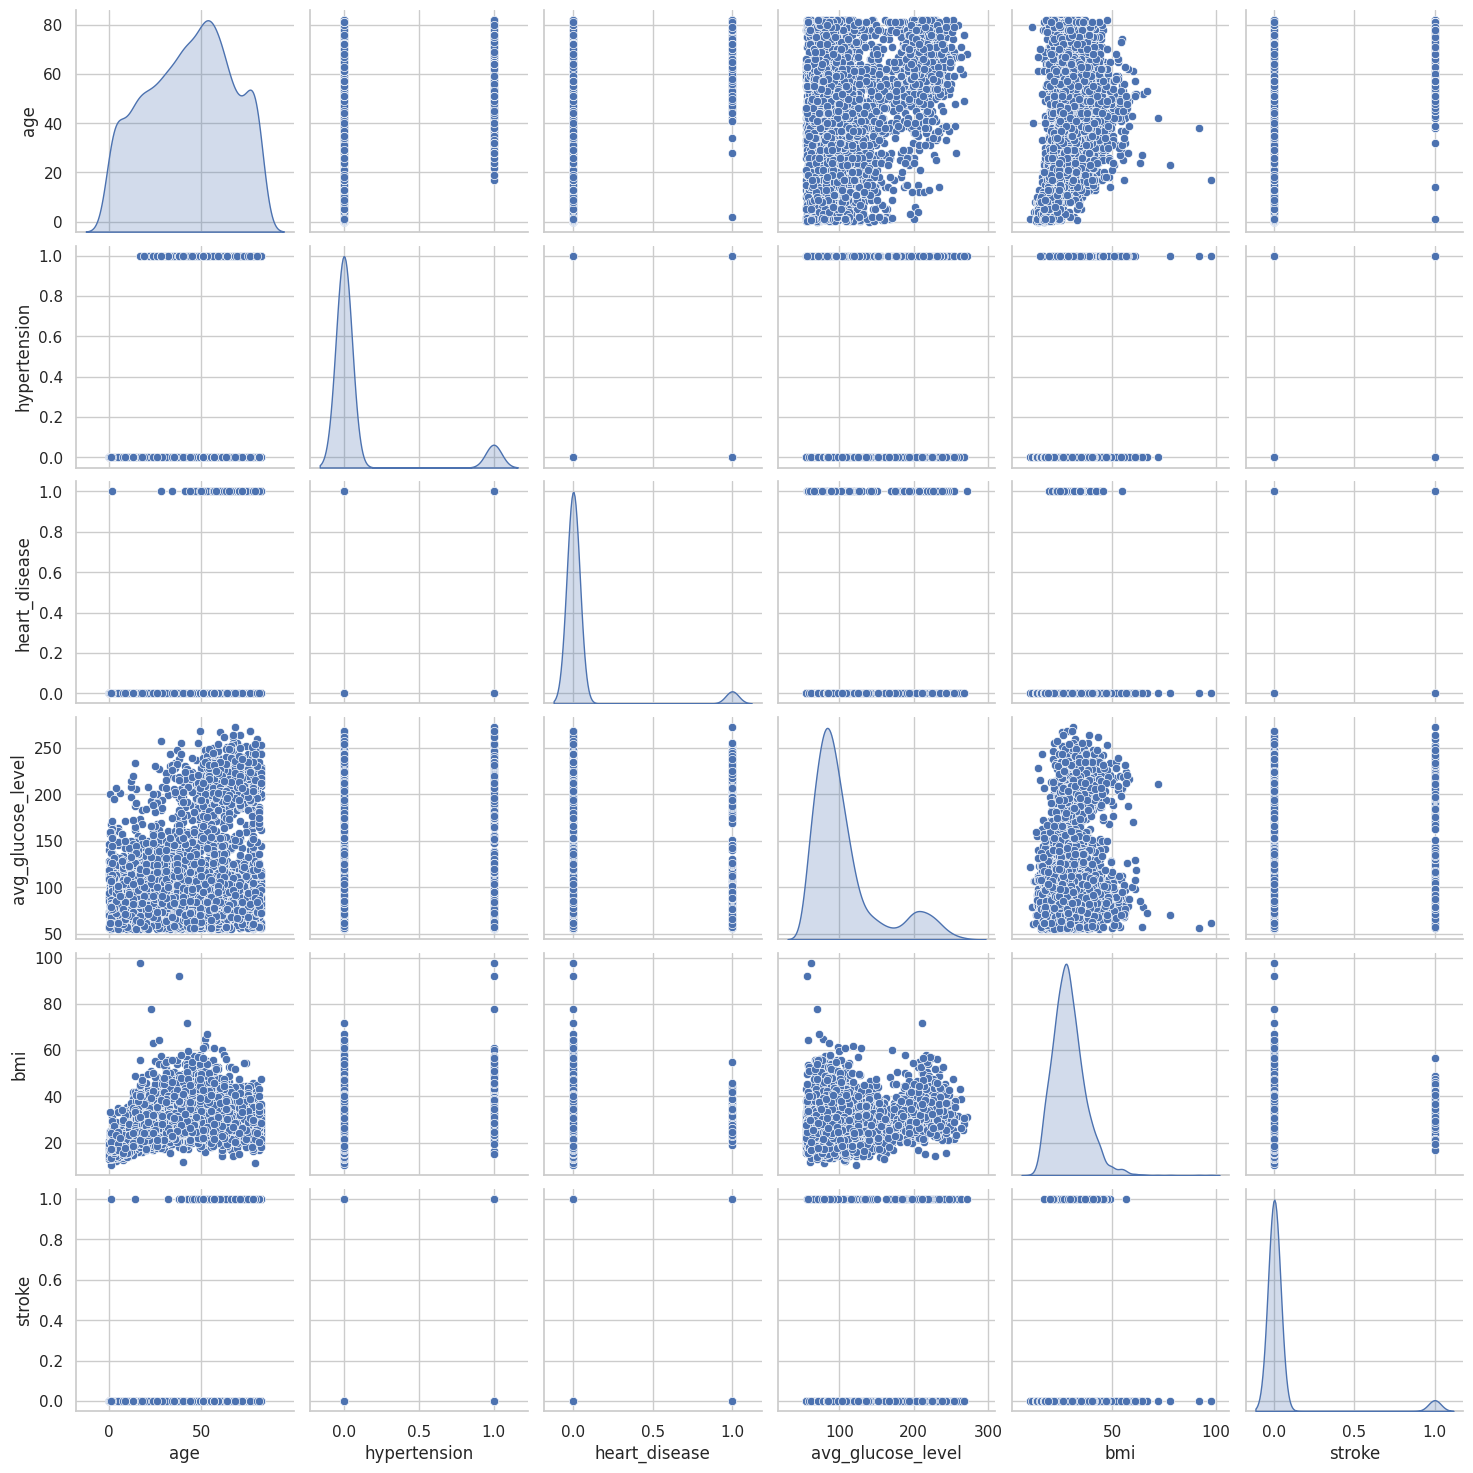

In [8]:
sns.pairplot(df[numeric_features], diag_kind='kde')
plt.show()

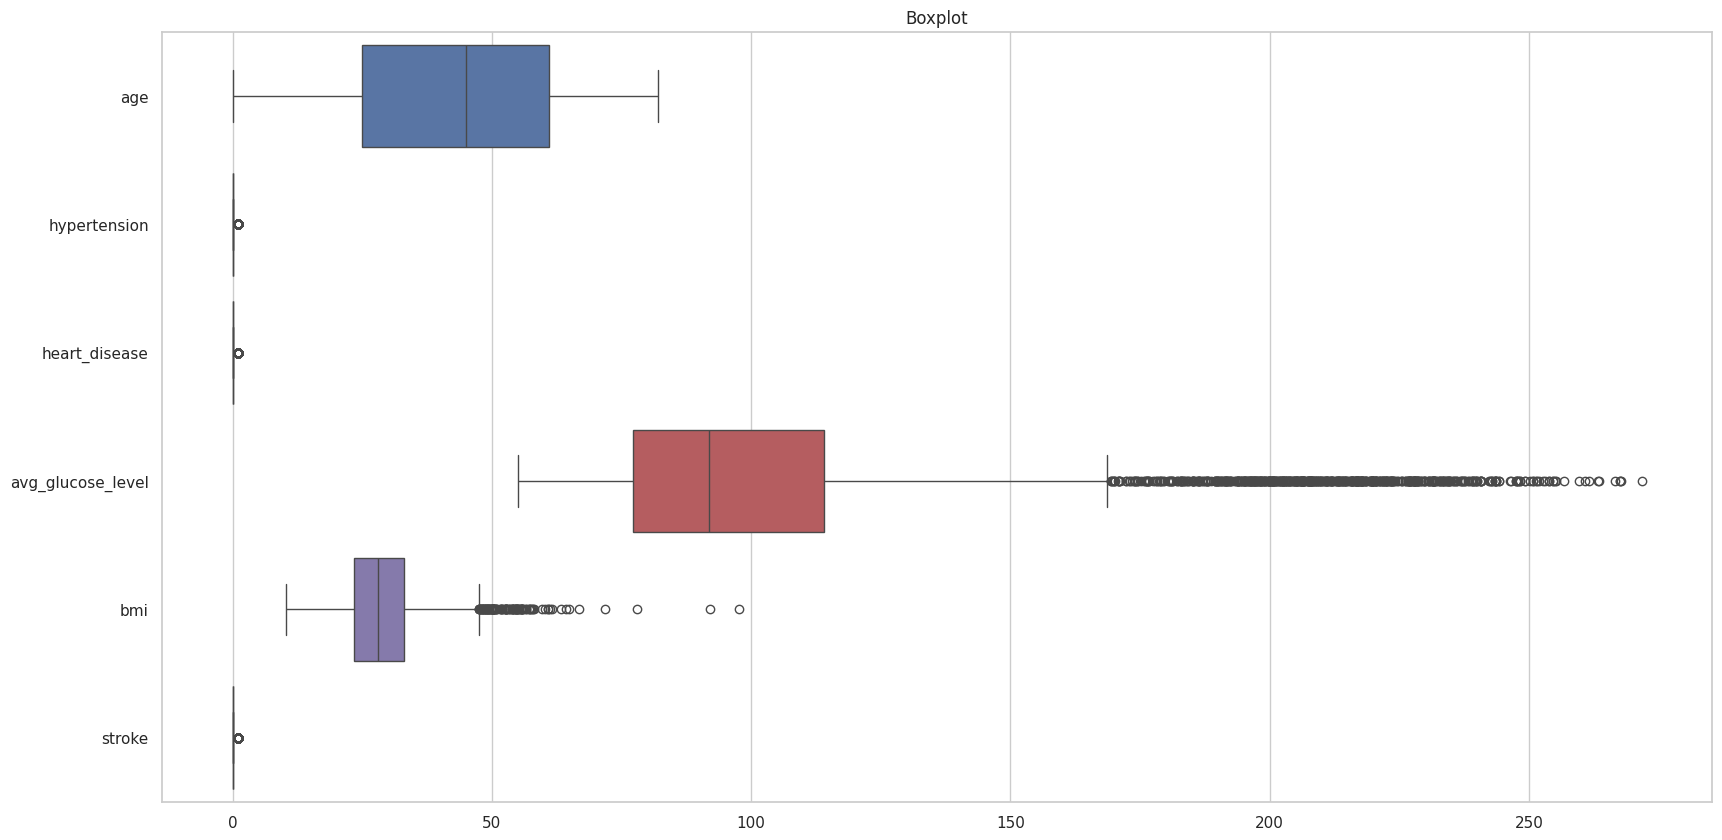

In [9]:
plt.figure(figsize=(20, 10))
sns.boxplot(df, orient='h')
plt.title('Boxplot')
plt.show()

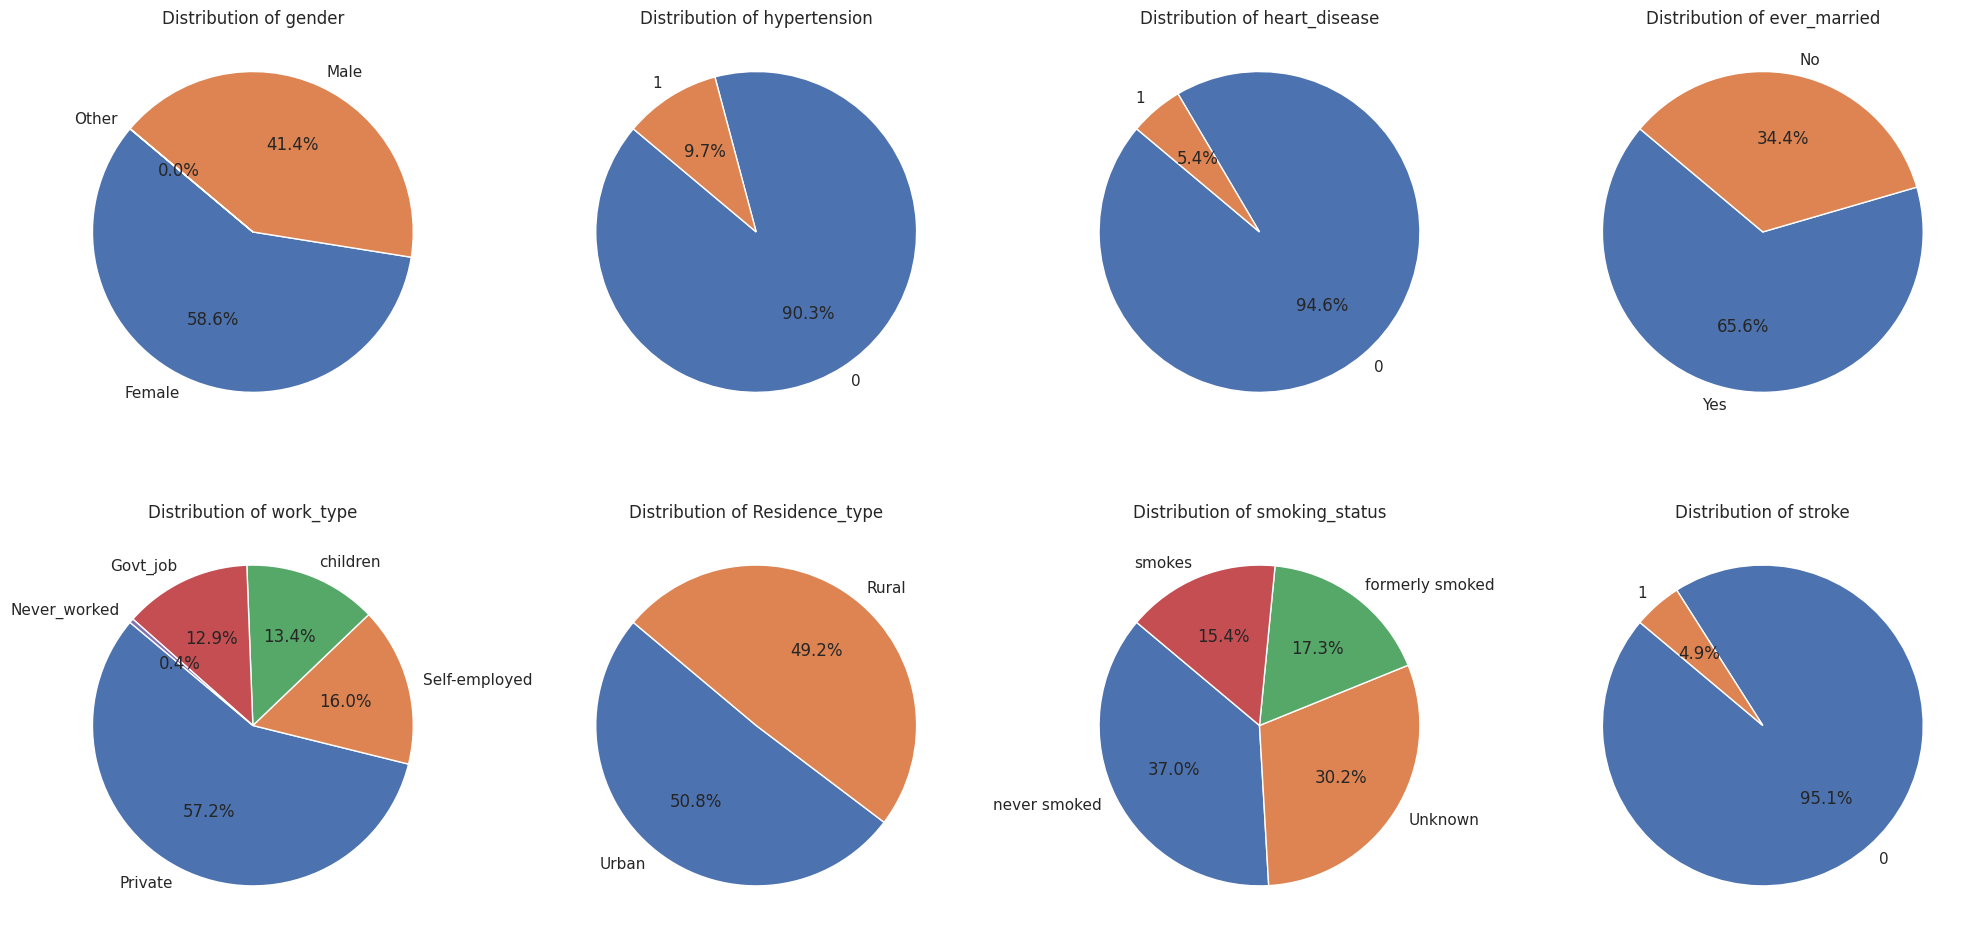

In [10]:
def compact_pie_chart(df, column, ax):
    counts = df[column].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
#    ax.legend(title=f'{column} Distribution', labels=[f'{label}: {count}' for label, count in counts.items()], title_fontsize='7', fontsize='5', loc='best')
    ax.set_title(f'Distribution of {column}')

# Exclude numeric columns or bin them
categorical_columns = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'stroke']

# Adjust subplot grid (e.g., 3x4 for 11 plots)
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
axes = axes.flatten()

for ax, column in zip(axes, categorical_columns):
    compact_pie_chart(df, column, ax)

# Hide unused subplots
for i in range(len(categorical_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install tqdm
!pip install ipympl
!pip install mlflow
!pip install scipy
!pip install h2o
!pip install ydata_profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.7/515.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 692.3/692.3 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0

In [12]:
import os
import shutil
import joblib

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder,StandardScaler, MinMaxScaler, RobustScaler

from sklearn.metrics import classification_report,accuracy_score, confusion_matrix, roc_auc_score, roc_curve, auc, f1_score, precision_score, recall_score

from sklearn.decomposition import PCA

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, cross_val_predict, cross_validate, train_test_split

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB,BernoulliNB,CategoricalNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from sklearn.model_selection import ParameterGrid
from sklearn.decomposition import LatentDirichletAllocation as LDA
import h2o
from h2o.automl import H2OAutoML
from ydata_profiling import ProfileReport
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import optuna
from optuna.integration import OptunaSearchCV
from optuna.distributions import FloatDistribution

## dealing with missing values

### removing rows with missing bmi value

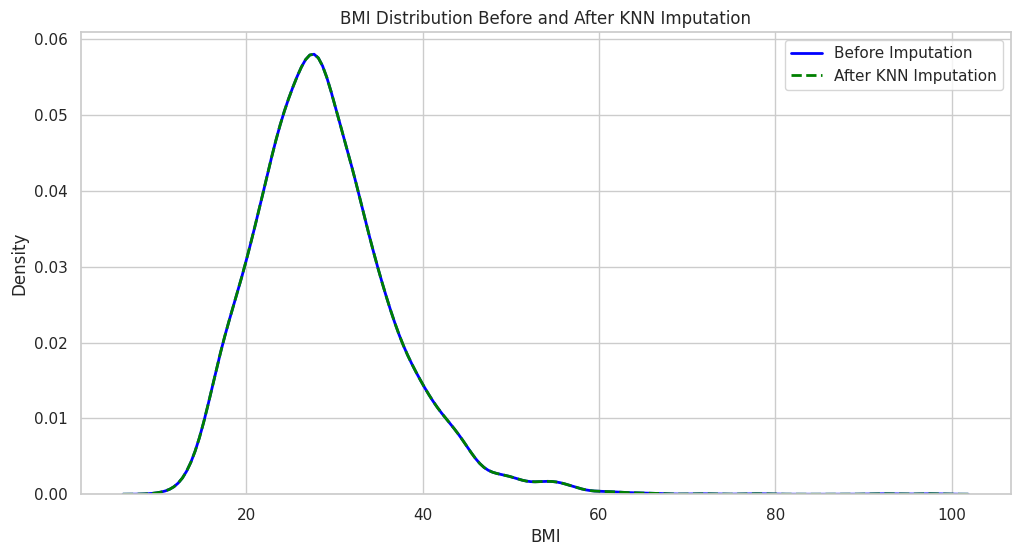

Before Imputation:
count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

After Imputation:
count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64
stroke
0    95.742514
1     4.257486
Name: proportion, dtype: float64


In [ ]:
df_clean = df.copy()
df_clean = df.dropna(subset=['bmi'])
# Before imputation: original BMI values (drop NaNs)
bmi_before = df['bmi'].dropna()

# After imputation: new BMI values (full column)
bmi_after = df_clean['bmi']

plt.figure(figsize=(12, 6))
sns.kdeplot(bmi_before, label='Before Imputation', color='blue', linewidth=2)
sns.kdeplot(bmi_after, label='After KNN Imputation', color='green', linestyle='--', linewidth=2)
plt.title('BMI Distribution Before and After KNN Imputation')
plt.xlabel('BMI')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

print("Before Imputation:")
print(bmi_before.describe())
print("\nAfter Imputation:")
print(bmi_after.describe())

stroke_percent = df_clean['stroke'].value_counts(normalize=True) * 100
print(stroke_percent)

stroke percentage dropped after removing lines with bmi nan value

### filling missing value by using median

<ipython-input-16-63bb1ba89d21>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['bmi'].fillna(df_clean['bmi'].median(), inplace=True)


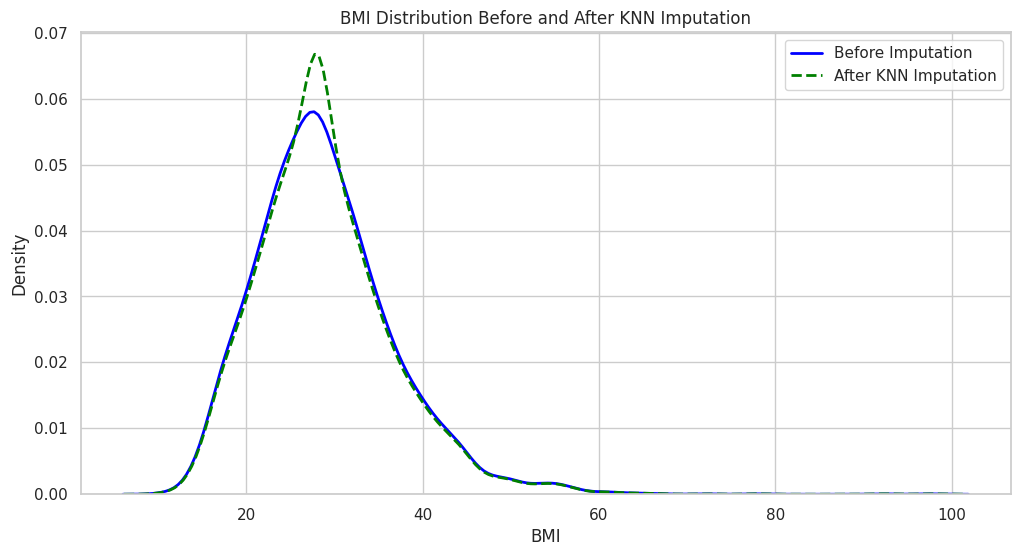

Before Imputation:
count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

After Imputation:
count    5110.000000
mean       28.862035
std         7.699562
min        10.300000
25%        23.800000
50%        28.100000
75%        32.800000
max        97.600000
Name: bmi, dtype: float64
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [ ]:
df_clean = df.copy()
df_clean['bmi'].fillna(df_clean['bmi'].median(), inplace=True)

# After imputation: new BMI values (full column)
bmi_after = df_clean['bmi']

plt.figure(figsize=(12, 6))
sns.kdeplot(bmi_before, label='Before Imputation', color='blue', linewidth=2)
sns.kdeplot(bmi_after, label='After KNN Imputation', color='green', linestyle='--', linewidth=2)
plt.title('BMI Distribution Before and After KNN Imputation')
plt.xlabel('BMI')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

print("Before Imputation:")
print(bmi_before.describe())
print("\nAfter Imputation:")
print(bmi_after.describe())

stroke_percent = df_clean['stroke'].value_counts(normalize=True) * 100
print(stroke_percent)

difference in mean is large so is std

### filling missing value by using mean

<ipython-input-21-7df06fd5388c>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['bmi'].fillna(df_clean['bmi'].mean(), inplace=True)


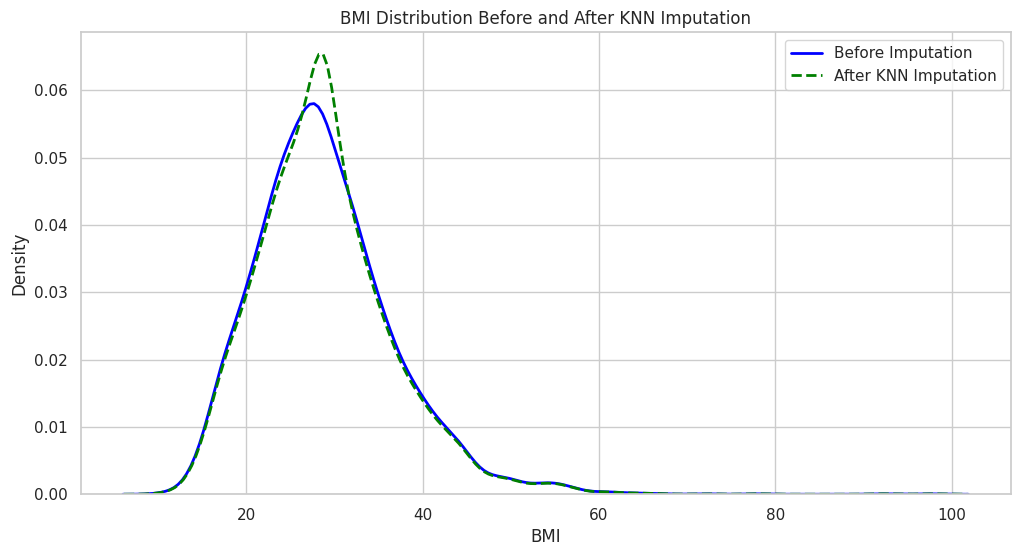

Before Imputation:
count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

After Imputation:
count    5110.000000
mean       28.893237
std         7.698018
min        10.300000
25%        23.800000
50%        28.400000
75%        32.800000
max        97.600000
Name: bmi, dtype: float64
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [ ]:
df_clean = df.copy()
df_clean['bmi'].fillna(df_clean['bmi'].mean(), inplace=True)

# After imputation: new BMI values (full column)
bmi_after = df_clean['bmi']

plt.figure(figsize=(12, 6))
sns.kdeplot(bmi_before, label='Before Imputation', color='blue', linewidth=2)
sns.kdeplot(bmi_after, label='After KNN Imputation', color='green', linestyle='--', linewidth=2)
plt.title('BMI Distribution Before and After KNN Imputation')
plt.xlabel('BMI')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

print("Before Imputation:")
print(bmi_before.describe())
print("\nAfter Imputation:")
print(bmi_after.describe())

stroke_percent = df_clean['stroke'].value_counts(normalize=True) * 100
print(stroke_percent)

difference in std is large so is 25, 50 and 75%

### filling missing value by using KNN

In [2]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Copy your original DataFrame
df_clean = df.copy()

# Select features to include in KNN (numerical ones + related ones)
# We'll encode categorical features numerically
knn_features = df_clean[['age', 'avg_glucose_level', 'bmi']].copy()

# Fill bmi NaNs with np.nan to be clear
knn_features['bmi'] = knn_features['bmi'].astype(float)

# Scaling: KNN is distance-based, so scale everything
scaler = StandardScaler()
knn_scaled = scaler.fit_transform(knn_features)

# Apply KNN Imputer
imputer = KNNImputer(n_neighbors=5)
knn_imputed = imputer.fit_transform(knn_scaled)

# Inverse scale to get back to original values
knn_inverse = scaler.inverse_transform(knn_imputed)

# Replace BMI values in the original DataFrame
df_clean['bmi'] = knn_inverse[:, 2]

# ✅ Confirm
print(f"Missing BMI values after KNN imputation: {df_clean['bmi'].isnull().sum()}")


Missing BMI values after KNN imputation: 0


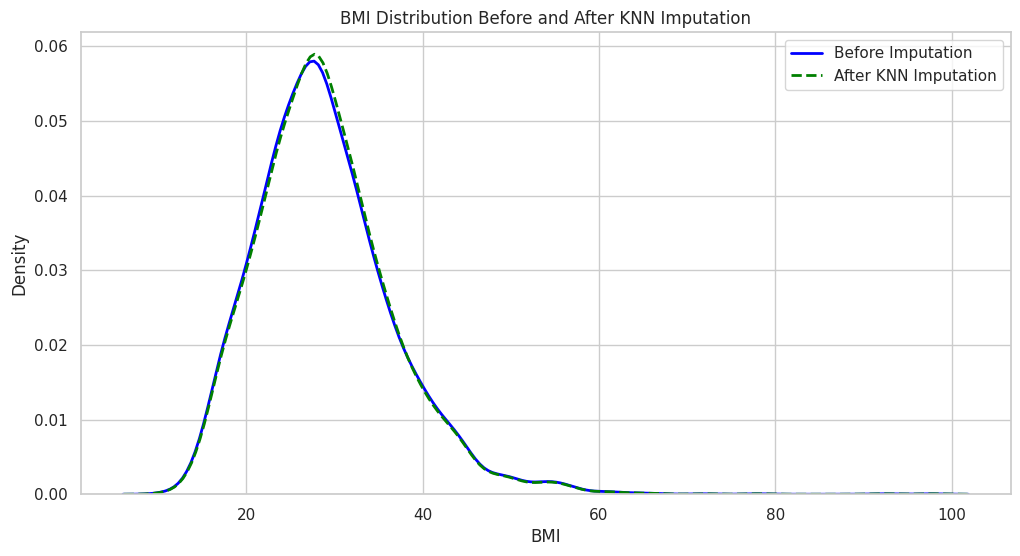

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Before imputation: original BMI values (drop NaNs)
bmi_before = df['bmi'].dropna()

# After imputation: new BMI values (full column)
bmi_after = df_clean['bmi']

plt.figure(figsize=(12, 6))
sns.kdeplot(bmi_before, label='Before Imputation', color='blue', linewidth=2)
sns.kdeplot(bmi_after, label='After KNN Imputation', color='green', linestyle='--', linewidth=2)
plt.title('BMI Distribution Before and After KNN Imputation')
plt.xlabel('BMI')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


In [14]:
print("Before Imputation:")
print(bmi_before.describe())
print("\nAfter Imputation:")
print(bmi_after.describe())

stroke_percent = df_clean['stroke'].value_counts(normalize=True) * 100
print(stroke_percent)

Before Imputation:
count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

After Imputation:
count    5110.000000
mean       28.950661
std         7.763918
min        10.300000
25%        23.700000
50%        28.200000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


difference in mean and std is minimal and percentage remained the same

## PCA

In [ ]:
def apply_PCA(n_components, df_clean):
    pca = PCA(n_components=n_components)
    pca_df_clean = pca.fit_transform(df_clean)
    return pca_df_clean, pca

In [ ]:
def pca(n_components, df_clean):
    pca_df_clean, pca = apply_PCA(n_components, df_clean)
    print('Explained Variance Ratio :',pca.explained_variance_ratio_)
    print('Explained Variance :',pca.explained_variance_)
    return pca_df_clean,pca

In [ ]:
def plot_2d(df_clean):

    numeric_columns = df_clean.select_dtypes(include=['number']).columns
    if len(numeric_columns) >= 2:
        # 2D Plot
        plt.figure(figsize=(8, 6))
        plt.scatter(df_clean[numeric_columns[0]], df_clean[numeric_columns[1]], c='blue', alpha=0.6)
        plt.title(f"2D Scatter Plot ({numeric_columns[0]} vs {numeric_columns[1]})")
        plt.xlabel(numeric_columns[0])
        plt.ylabel(numeric_columns[1])
        plt.grid(True)
        plt.show()
    else:
        print("The DataFrame must have at least 2 numerical columns for plotting.")


In [ ]:
PCA_1D=PCA(n_components=1)
PCA_2D=PCA(n_components=2)

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Assuming `data` is your DataFrame
df_encoded = df_clean.copy()

# Manually define categorical columns (replace with your actual categorical columns)
categorical_columns = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Initialize LabelEncoder
le = LabelEncoder()

# Encode each categorical column
for column in categorical_columns:
    df_encoded[column] = le.fit_transform(df_encoded[column])

# Verify encoding
print(df_encoded.head())

   gender   age  hypertension  heart_disease  ever_married  work_type  \
0       1  67.0             0              1             1          2   
1       0  61.0             0              0             1          3   
2       1  80.0             0              1             1          2   
3       0  49.0             0              0             1          2   
4       0  79.0             1              0             1          3   

   Residence_type  avg_glucose_level    bmi  smoking_status  stroke  
0               1             228.69  36.60               1       1  
1               0             202.21  31.14               2       1  
2               0             105.92  32.50               2       1  
3               1             171.23  34.40               3       1  
4               0             174.12  24.00               2       1  


In [ ]:
data_PCA_1D,PCA_1D=apply_PCA(1,df_encoded)

In [ ]:
PCA_1D.explained_variance_ratio_

array([0.79641161])

In [ ]:
data_PCA_1D = pd.DataFrame(data_PCA_1D, columns=['PCA_F1'])
data_PCA_1D['stroke'] = df_encoded['stroke'].values

In [ ]:
data_PCA_1D.head()

,PCA_F1,stroke
0,124.935862,1
1,97.669056,1
2,5.562133,1
3,65.352460,1
4,72.446502,1


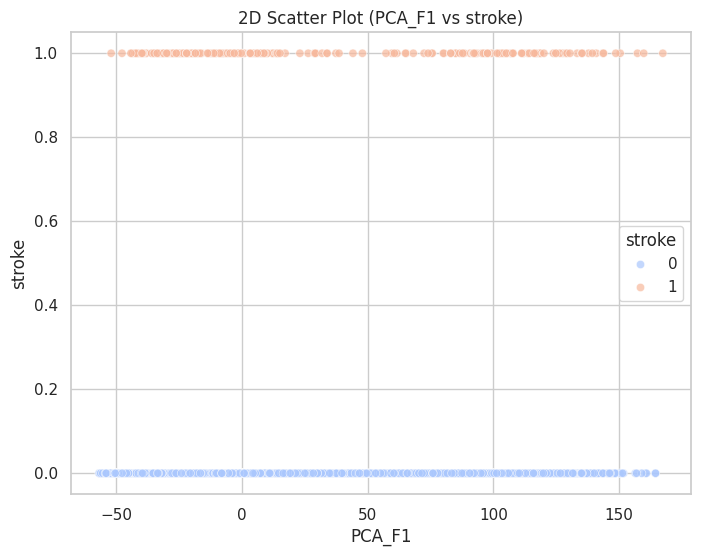

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data_PCA_1D['PCA_F1'], y=data_PCA_1D['stroke'], hue=data_PCA_1D['stroke'], palette='coolwarm', alpha=0.7)
plt.title("2D Scatter Plot (PCA_F1 vs stroke)")
plt.xlabel('PCA_F1')
plt.ylabel('stroke')
plt.grid(True)
plt.show()

In [ ]:
data_PCA_2D,PCA_2D=apply_PCA(2,df_encoded)

In [ ]:
PCA_2D.explained_variance_ratio_

array([0.79641161, 0.18260617])

In [ ]:
data_PCA_2D = pd.DataFrame(data_PCA_2D, columns=['PCA_F1','PCA_F2'])
data_PCA_2D['stroke'] = df_encoded['stroke'].values

In [ ]:
data_PCA_2D.head()

,PCA_F1,PCA_F2,stroke
0,124.935862,4.953680,1
1,97.669056,2.600565,1
2,5.562133,36.521226,1
3,65.352460,-3.905731,1
4,72.446502,23.857870,1


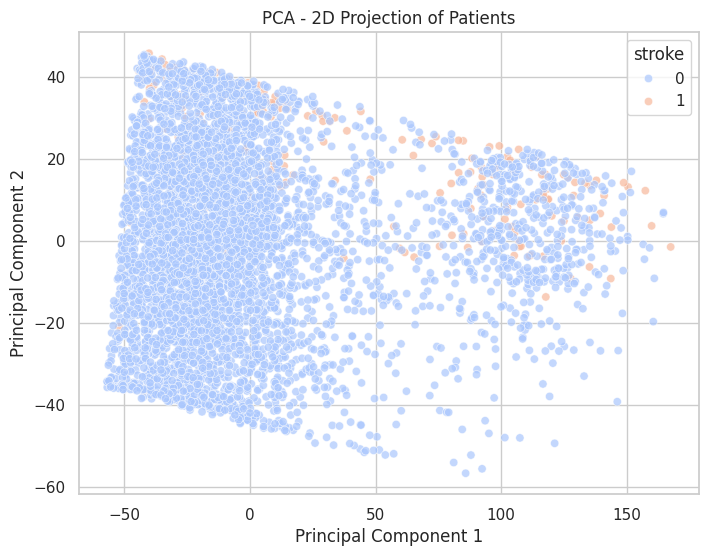

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=data_PCA_2D['PCA_F1'], y=data_PCA_2D['PCA_F2'], hue=data_PCA_2D['stroke'], palette='coolwarm', alpha=0.7)
plt.title("PCA - 2D Projection of Patients")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

In [ ]:
def plot_PCA_2D(data, columns, target):
    # Apply PCA
    pca = PCA(n_components=1)
    pca_data = pca.fit_transform(data[columns])
    pca_df = pd.DataFrame(pca_data, columns=['PCA_1D'])
    pca_df[target] = data[target].values

    # Plot before PCA
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    # scatterplot returns an object that can be used to create a colorbar
    scatter = sns.scatterplot(x=data[columns[0]], y=data[columns[1]], hue=data[target], palette='coolwarm', alpha=0.7)

    plt.title("Before PCA")
    plt.xlabel(columns[0])
    plt.ylabel(columns[1])
    # Use the scatterplot object to create the colorbar
    plt.colorbar(scatter.collections[0], label=target)
    plt.grid(True)

    # Plot after PCA
    plt.subplot(1, 2, 2)
    # scatterplot returns an object that can be used to create a colorbar
    scatter = sns.scatterplot(x=pca_df['PCA_1D'], y=pca_df[target], hue=pca_df[target], palette='coolwarm', alpha=0.7)

    plt.title("After PCA")
    plt.xlabel('PCA_1D')
    plt.ylabel(target)
    # Use the scatterplot object to create the colorbar
    plt.colorbar(scatter.collections[0], label=target)
    plt.grid(True)

    plt.tight_layout()
    plt.show()

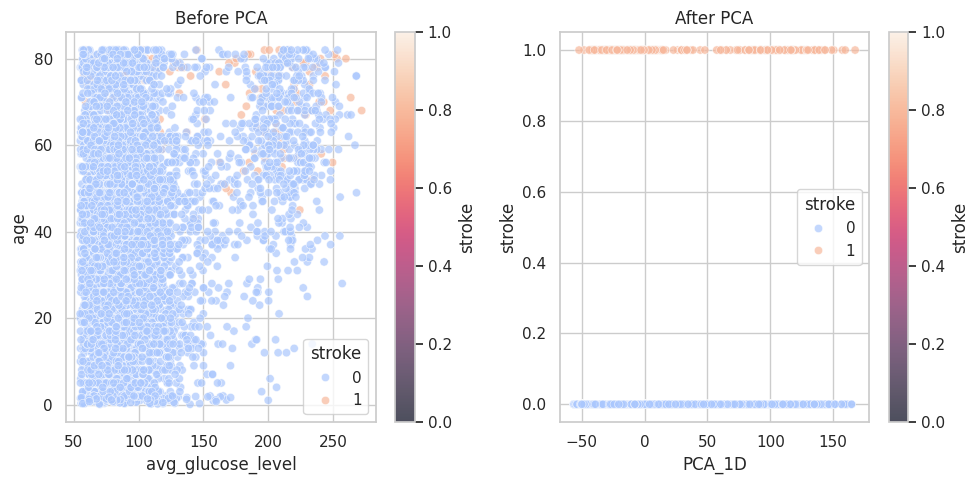

In [ ]:
plot_PCA_2D(df_clean,['avg_glucose_level','age'],'stroke')

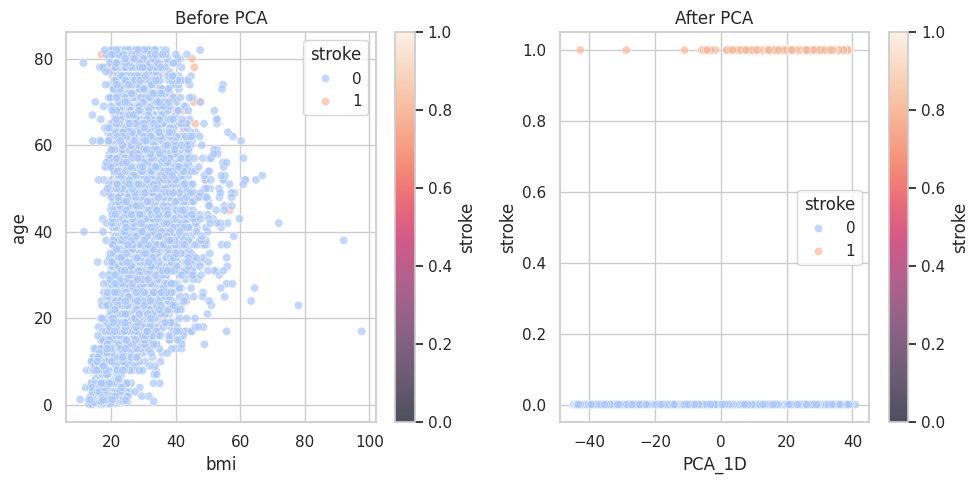

In [ ]:
plot_PCA_2D(df_clean,['bmi','age'],'stroke')

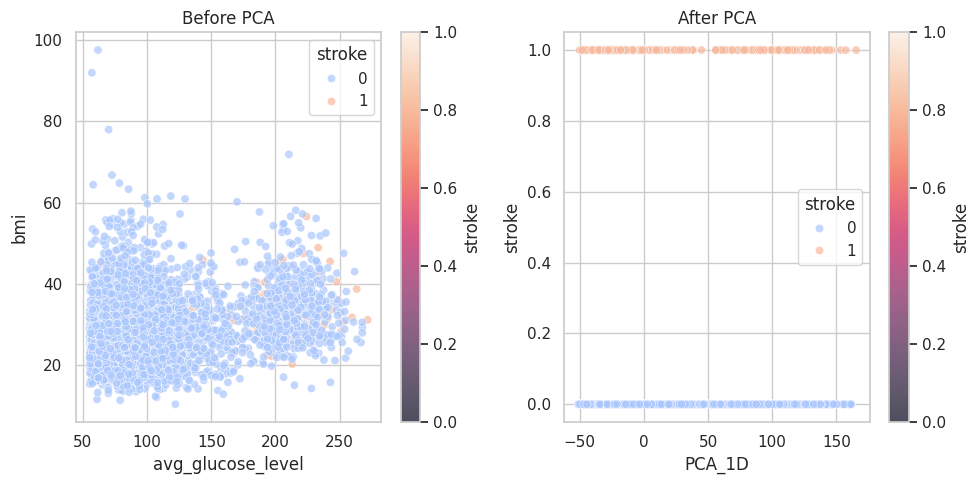

In [ ]:
plot_PCA_2D(df_clean,['avg_glucose_level','bmi'],'stroke')

## LDA

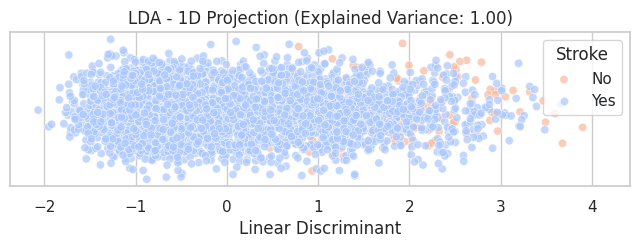

In [ ]:
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load data (assuming df_clean is preprocessed)
X = df_clean.drop('stroke', axis=1)
y = df_clean['stroke']

# Encode categorical variables (one-hot for nominal, ordinal for ordered)
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Standardize numerical features (optional but recommended)
numerical_cols = ['age', 'avg_glucose_level', 'bmi']  # Adjust based on your data
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Apply LDA
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X, y)

# Explained variance
explained_variance = lda.explained_variance_ratio_[0]

# Plot with jitter
plt.figure(figsize=(8, 2))
jitter_y = np.random.normal(0, 0.05, size=len(X_lda))
sns.scatterplot(
    x=X_lda[:, 0],
    y=jitter_y,
    hue=y,
    palette='coolwarm',
    alpha=0.7,
)
plt.title(f"LDA - 1D Projection (Explained Variance: {explained_variance:.2f})")
plt.xlabel("Linear Discriminant")
plt.yticks([])
plt.grid(True)
plt.legend(title='Stroke', labels=['No', 'Yes'])
plt.show()

## t-SNE

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


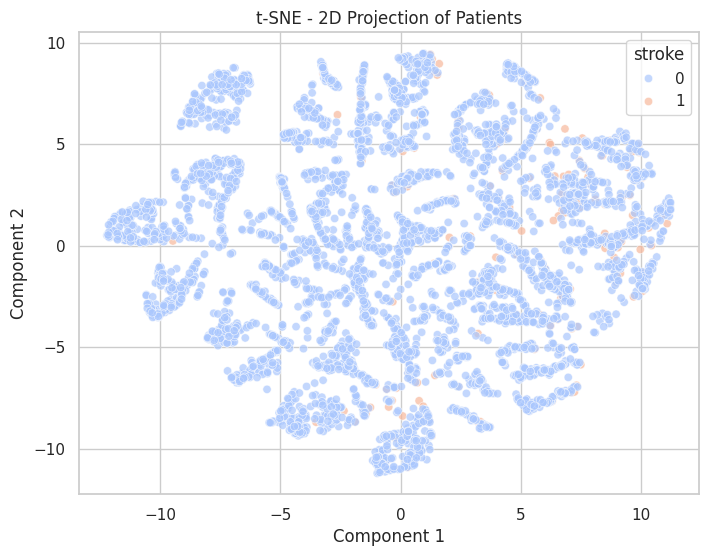

In [ ]:
from sklearn.manifold import TSNE

# Optional: Reduce to 50D with PCA before t-SNE (recommended)
# Change n_components to a value less than or equal to 17
X_pca_50 = PCA(n_components=min(50, X.shape[1])).fit_transform(X)
# X.shape[1] gives the number of features, ensuring n_components is within the allowed range.

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=300, random_state=42)
X_tsne = tsne.fit_transform(X_pca_50)

# Plot t-SNE result
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='coolwarm', alpha=0.7)
plt.title("t-SNE - 2D Projection of Patients")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()

## dealing with outliers

In [3]:
# Function to remove outliers using IQR
def remove_outliers(df_clean, col):
    Q1 = df_clean[col].quantile(0.01)
    Q3 = df_clean[col].quantile(0.99)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

numerical_cols = ['age', 'avg_glucose_level', 'bmi']

# Remove outliers for numerical features
for col in numerical_cols:
    df_clean = remove_outliers(df_clean, col)

### visualization after removing outliers

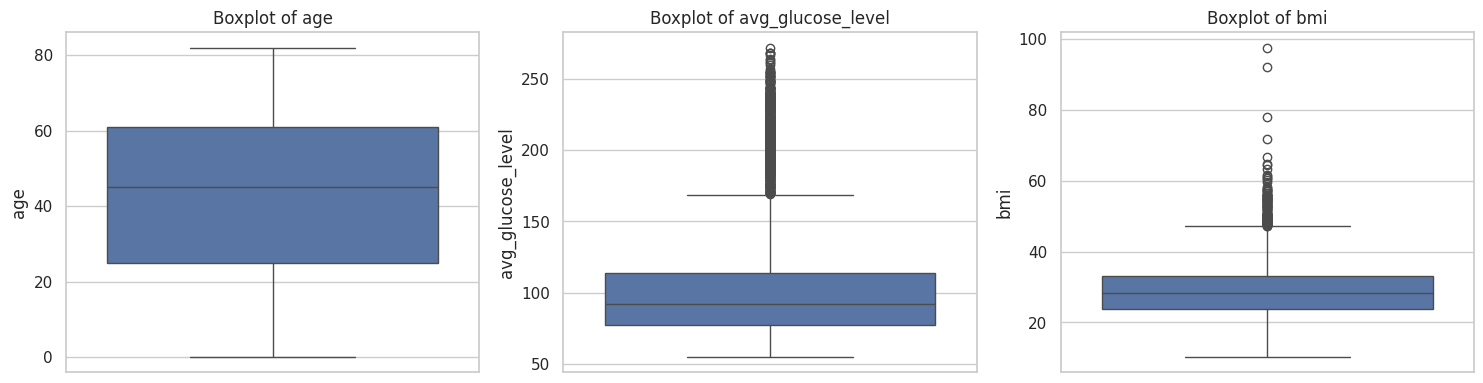

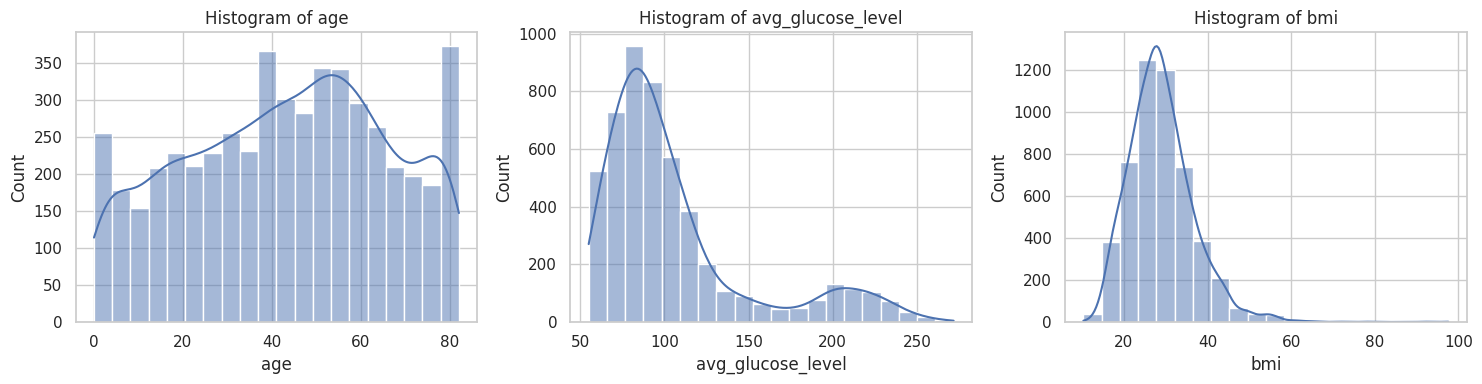

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numeric columns to check
numeric_cols = ['age', 'avg_glucose_level', 'bmi']

# Boxplots
plt.figure(figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df_clean[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Histograms
plt.figure(figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    plt.subplot(1, 3, i+1)
    sns.histplot(df_clean[col], bins=20, kde=True)
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()


## Correlation matrix

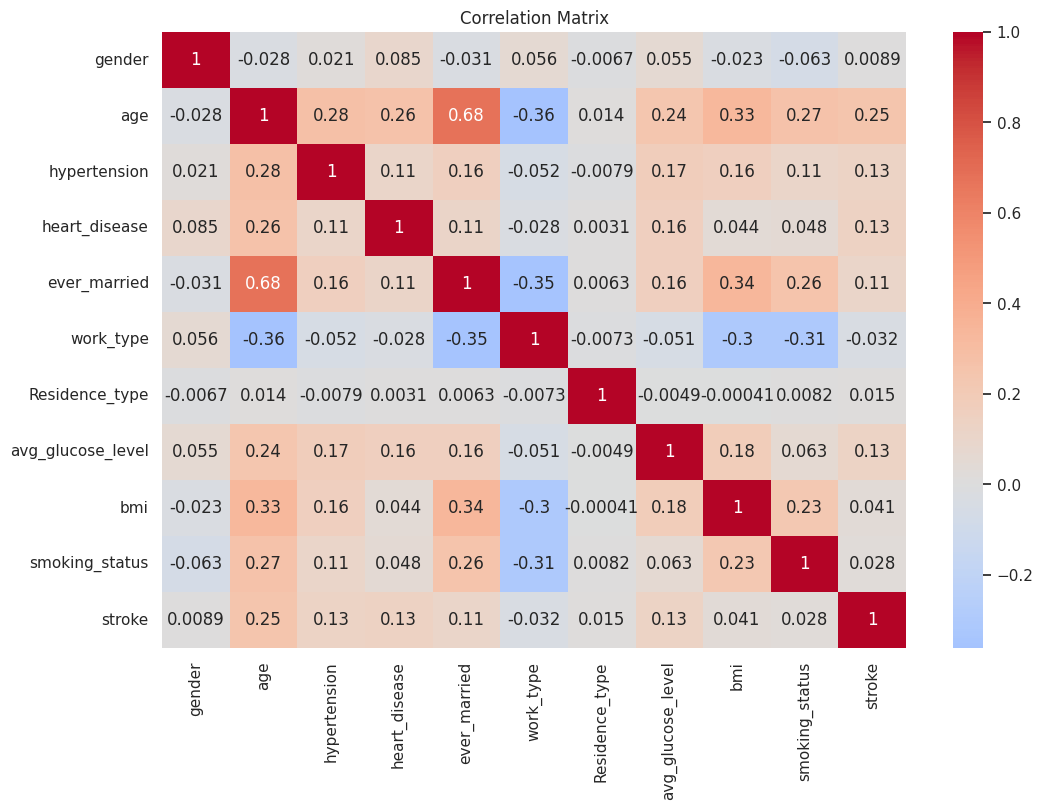

In [17]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables for correlation
encoded_data = df_clean.copy()
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
le = LabelEncoder()
for col in categorical_cols:
    encoded_data[col] = le.fit_transform(encoded_data[col])

plt.figure(figsize=(12, 8))
sns.heatmap(encoded_data.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [18]:
stroke_percent = df_clean['stroke'].value_counts(normalize=True) * 100
print(stroke_percent)


stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


#  Data Cleaning and Preprocessing

## encoding dataset

In [46]:
from sklearn.preprocessing import LabelEncoder

# Make sure you're working with the corrected dataframe
df_oh = df_clean.copy()

# Then redo the encoding
le = LabelEncoder()
df_oh['ever_married'] = le.fit_transform(df_oh['ever_married'])
df_oh['Residence_type'] = le.fit_transform(df_oh['Residence_type'])

# One-hot encoding
df_oh = pd.get_dummies(df_oh, columns=['gender', 'work_type', 'smoking_status'] , dtype=int)
# Verify
print(df_oh.columns)
df_oh.head()

Index(['age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'bmi', 'stroke', 'gender_Female',
       'gender_Male', 'gender_Other', 'work_type_Govt_job',
       'work_type_Never_worked', 'work_type_Private',
       'work_type_Self-employed', 'work_type_children',
       'smoking_status_Unknown', 'smoking_status_formerly smoked',
       'smoking_status_never smoked', 'smoking_status_smokes'],
      dtype='object')


,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,1,1,228.69,36.60,1,0,1,0,0,0,1,0,0,0,1,0,0
1,61.0,0,0,1,0,202.21,31.14,1,1,0,0,0,0,0,1,0,0,0,1,0
2,80.0,0,1,1,0,105.92,32.50,1,0,1,0,0,0,1,0,0,0,0,1,0
3,49.0,0,0,1,1,171.23,34.40,1,1,0,0,0,0,1,0,0,0,0,0,1
4,79.0,1,0,1,0,174.12,24.00,1,1,0,0,0,0,0,1,0,0,0,1,0


### Correlation matrix after encoding

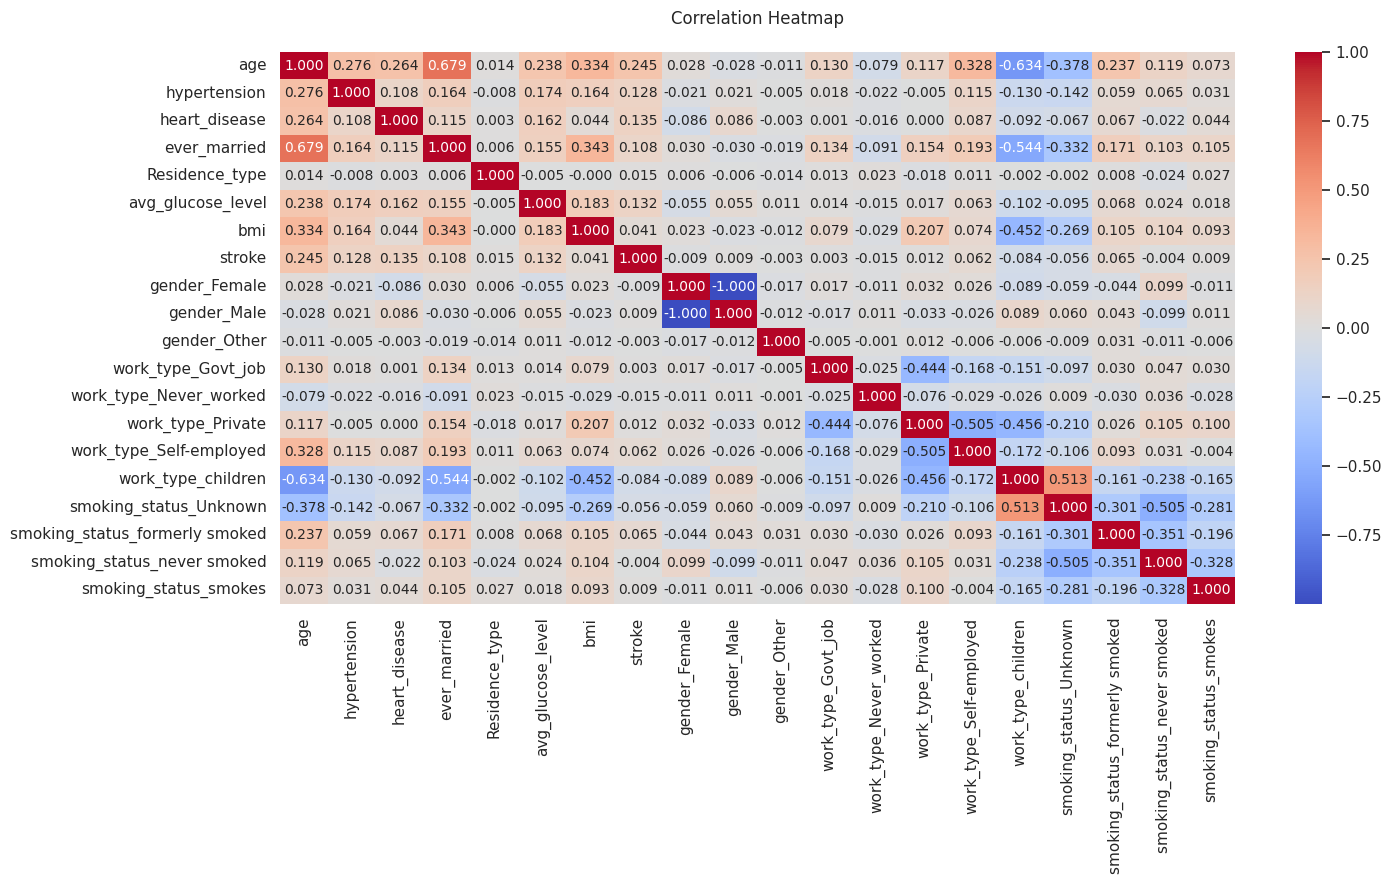

In [20]:
# Drop non-numerical columns for correlation heatmap
num_df = df_oh.select_dtypes(include=[np.number])

# Correlation matrix
corr = num_df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(15, 9))  # You can adjust these dimensions (width, height)

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".3f",
            annot_kws={"size": 10})  # You can adjust the font size here
plt.title("Correlation Heatmap", pad=20)  # Add some padding to the title
plt.tight_layout()  # Helps with spacing
plt.show()

# Models with no hyper parameter tuning

## Data splitting

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_oh.drop('stroke', axis=1)
y = df_oh['stroke']

# First, split off the test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

# Then, split the remaining into train (70%) and validation (15% of original total)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)  # 0.1765 * 85% ≈ 15%

# Show the size of each set
print(f"Train set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Also, show class distribution to ensure balance
print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))


Train set: 3576 samples
Validation set: 767 samples
Test set: 767 samples

Class distribution in training set:
stroke
0    0.951063
1    0.048937
Name: proportion, dtype: float64


## Naïve Bayes no hyper parameter tuning

=== Naïve Bayes Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.31      0.48       730
           1       0.07      0.97      0.13        37

    accuracy                           0.34       767
   macro avg       0.53      0.64      0.30       767
weighted avg       0.95      0.34      0.46       767



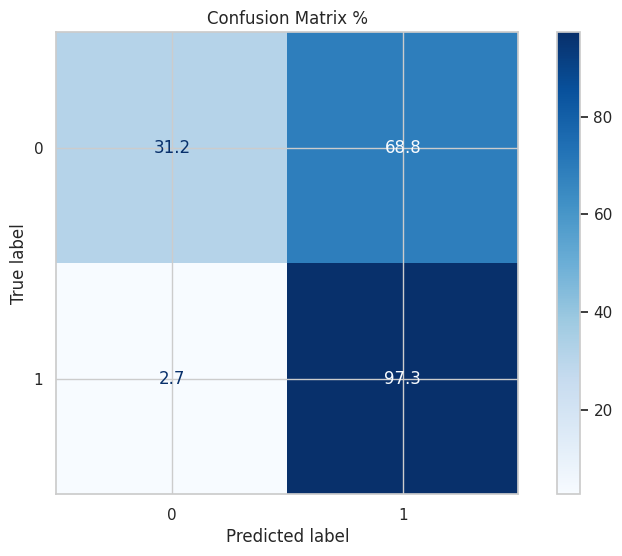

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train the model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predict on validation set
y_val_pred_nb = nb_model.predict(X_val)

# Evaluate
print("=== Naïve Bayes Classification Report ===")
print(classification_report(y_val, y_val_pred_nb))

# Confusion Matrix in percentage
cm_nb = confusion_matrix(y_val, y_val_pred_nb)
cm_nb_percentage = cm_nb.astype('float') / cm_nb.sum(axis=1)[:, np.newaxis] * 100  # Convert to percentage

disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb_percentage,
                                display_labels=nb_model.classes_)
disp_nb.plot(cmap='Blues', values_format='.1f')  # '.1f' formats to 1 decimal place
plt.title("Confusion Matrix %")
plt.show()

## SVM no hyper parameter tuning

=== SVM Classification Report ===
              precision    recall  f1-score   support

           0       0.97      0.76      0.85       730
           1       0.11      0.57      0.18        37

    accuracy                           0.75       767
   macro avg       0.54      0.67      0.52       767
weighted avg       0.93      0.75      0.82       767



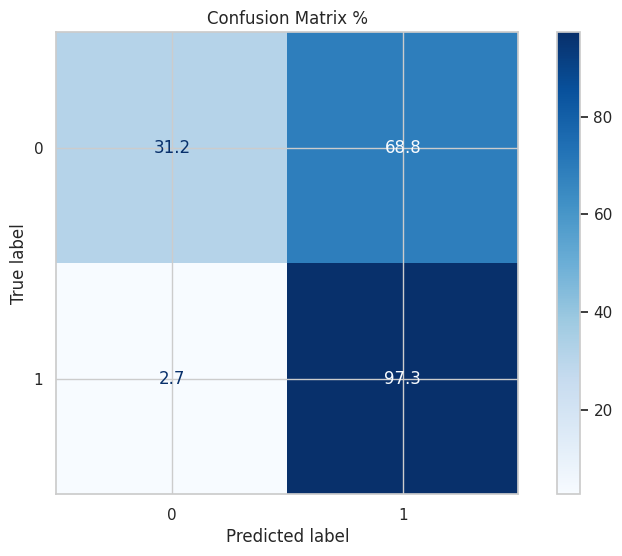

In [ ]:
# Build the pipeline (scaling + SVM)
svm_pipeline = make_pipeline(StandardScaler(), SVC(kernel='rbf', class_weight='balanced', random_state=42))

# Train the model
svm_pipeline.fit(X_train, y_train)

# Predict on validation set
y_pred_svm = svm_pipeline.predict(X_val)

# Evaluate
print("=== SVM Classification Report ===")
print(classification_report(y_val, y_pred_svm))

# Confusion Matrix in percentage
cm_nb = confusion_matrix(y_val, y_val_pred_nb)
cm_nb_percentage = cm_nb.astype('float') / cm_nb.sum(axis=1)[:, np.newaxis] * 100  # Convert to percentage

disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb_percentage,
                                display_labels=nb_model.classes_)
disp_nb.plot(cmap='Blues', values_format='.1f')  # '.1f' formats to 1 decimal place
plt.title("Confusion Matrix %")
plt.show()


# Models with hyper parameter tuning

In [47]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Set a consistent style for plots
sns.set_theme(style="whitegrid")


In [48]:

X = df_oh.drop('stroke', axis=1)
y = df_oh['stroke']


In [49]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [50]:
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
print(f"Training Set: {X_train.shape}, Validation Set: {X_val.shape}, Testing Set: {X_test.shape}")

Training Set: (3066, 19), Validation Set: (1022, 19), Testing Set: (1022, 19)


## Naïve Bayes with hyper parameter tuning

###  grid search

In [51]:
nb_model = GaussianNB()

# Define hyperparameter configurations
param_grid = {
    'var_smoothing': np.logspace(-9, 0, 50)  # Example parameter grid
}

# Perform grid search for hyperparameter tuning
grid_search = GridSearchCV(nb_model, param_grid, cv=5, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


GridSearchCV(cv=5, estimator=GaussianNB(),
             param_grid={'var_smoothing': array([1.00000000e-09, 1.52641797e-09, 2.32995181e-09, 3.55648031e-09,
       5.42867544e-09, 8.28642773e-09, 1.26485522e-08, 1.93069773e-08,
       2.94705170e-08, 4.49843267e-08, 6.86648845e-08, 1.04811313e-07,
       1.59985872e-07, 2.44205309e-07, 3.72759372e-07, 5.68986603e-07,
       8.68511374e-07, 1.32571137e-06, 2.02...
       1.38949549e-04, 2.12095089e-04, 3.23745754e-04, 4.94171336e-04,
       7.54312006e-04, 1.15139540e-03, 1.75751062e-03, 2.68269580e-03,
       4.09491506e-03, 6.25055193e-03, 9.54095476e-03, 1.45634848e-02,
       2.22299648e-02, 3.39322177e-02, 5.17947468e-02, 7.90604321e-02,
       1.20679264e-01, 1.84206997e-01, 2.81176870e-01, 4.29193426e-01,
       6.55128557e-01, 1.00000000e+00])},
             scoring='accuracy', verbose=1)

In [52]:
best_params = grid_search.best_params_
train_accuracy = grid_search.best_score_
val_accuracy = grid_search.score(X_val, y_val)

In [53]:
print(f"Best Parameters: {best_params}")
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Validation Accuracy: {val_accuracy:.2f}")

Best Parameters: {'var_smoothing': np.float64(1.0)}
Training Accuracy: 0.94
Validation Accuracy: 0.94


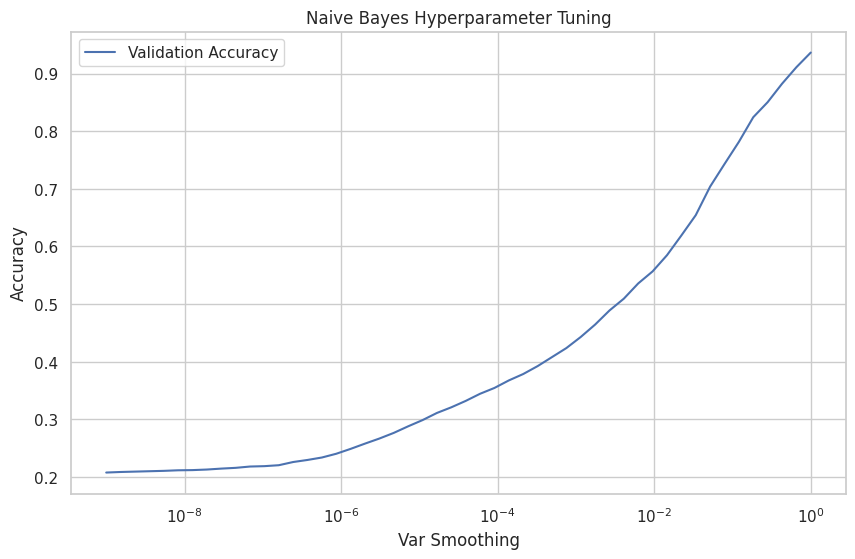

In [54]:
results = pd.DataFrame(grid_search.cv_results_)
plt.plot(results['param_var_smoothing'], results['mean_test_score'], label="Validation Accuracy")
plt.xscale('log')
plt.xlabel('Var Smoothing')
plt.ylabel('Accuracy')
plt.title('Naive Bayes Hyperparameter Tuning')
plt.legend()
plt.show()

In [55]:

y_test_pred = grid_search.predict(X_test)

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='weighted')
conf_matrix_test = confusion_matrix(y_test, y_test_pred)

In [56]:
print(f"Test Set Metrics:")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Test Set Metrics:
Precision: 0.92
Recall: 0.93
F1-Score: 0.93


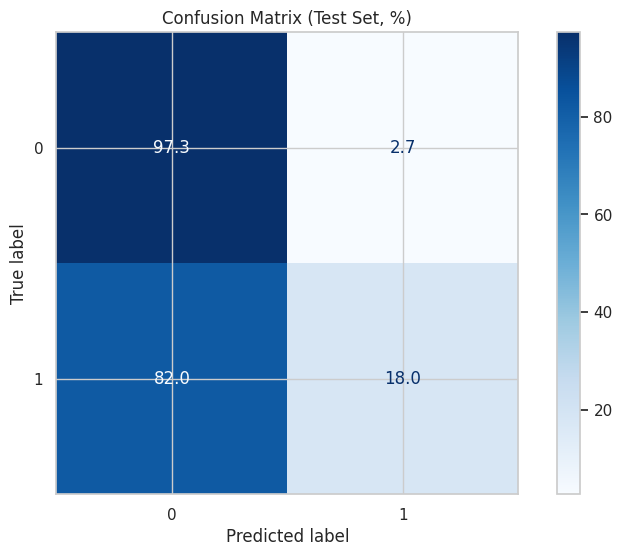

In [57]:
cm_percent = conf_matrix_test.astype('float') / conf_matrix_test.sum(axis=1)[:, np.newaxis] * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=grid_search.classes_)
disp.plot(cmap='Blues', values_format=".1f")  # Show percentages with 1 decimal
plt.title("Confusion Matrix (Test Set, %)")
plt.show()

In [58]:
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       972
           1       0.26      0.18      0.21        50

    accuracy                           0.93      1022
   macro avg       0.61      0.58      0.59      1022
weighted avg       0.92      0.93      0.93      1022



accuracy is much better than base model

### optuna search

In [ ]:
!pip install optuna

In [ ]:
!pip install optuna-integration[sklearn]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 kB 2.5 MB/s eta 0:00:00


In [59]:
# 3. Define Model
nb_model = GaussianNB()

# 4. Optuna Search
param_distributions = {
    'var_smoothing': FloatDistribution(1e-9, 1e0, log=True)  # Using FloatDistribution with log=True
}

In [60]:
optuna_search = OptunaSearchCV(
    nb_model,
    param_distributions,
    cv=5,
    n_trials=50,        # Number of trials (searches) to do
    random_state=42,
    scoring='accuracy',
    verbose=1,
    refit=True
)

<ipython-input-60-d9eaa06e4f3f>:1: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(


In [61]:
optuna_search.fit(X_train, y_train)


[I 2025-04-28 03:05:15,707] A new study created in memory with name: no-name-1728504b-d807-4f0e-8f3a-adeb281ab721
INFO:optuna_integration.sklearn.sklearn:Searching the best hyperparameters using 3066 samples...
[I 2025-04-28 03:05:15,742] Trial 0 finished with value: 0.302683443947904 and parameters: {'var_smoothing': 1.2368284599556906e-05}. Best is trial 0 with value: 0.302683443947904.
[I 2025-04-28 03:05:15,774] Trial 1 finished with value: 0.6484045464448353 and parameters: {'var_smoothing': 0.031166518451724804}. Best is trial 1 with value: 0.6484045464448353.
[I 2025-04-28 03:05:15,809] Trial 2 finished with value: 0.2107072070396565 and parameters: {'var_smoothing': 4.182751540781787e-09}. Best is trial 1 with value: 0.6484045464448353.
[I 2025-04-28 03:05:15,848] Trial 3 finished with value: 0.23875636985828227 and parameters: {'var_smoothing': 7.499378258136028e-07}. Best is trial 1 with value: 0.6484045464448353.
[I 2025-04-28 03:05:15,882] Trial 4 finished with value: 0.318

OptunaSearchCV(cv=5, estimator=GaussianNB(), n_jobs=1, n_trials=50,
               param_distributions={'var_smoothing': FloatDistribution(high=1.0, log=True, low=1e-09, step=None)},
               random_state=42, scoring='accuracy', verbose=1)

In [62]:
# 5. Best params and scores
best_params = optuna_search.best_params_
train_accuracy = optuna_search.best_score_
val_accuracy = optuna_search.score(X_val, y_val)

In [63]:
print(f"\nBest Parameters: {best_params}")
print(f"Training Accuracy (CV avg): {train_accuracy:.2f}")
print(f"Validation Accuracy: {val_accuracy:.2f}")



Best Parameters: {'var_smoothing': 0.9417202226157353}
Training Accuracy (CV avg): 0.94
Validation Accuracy: 0.93


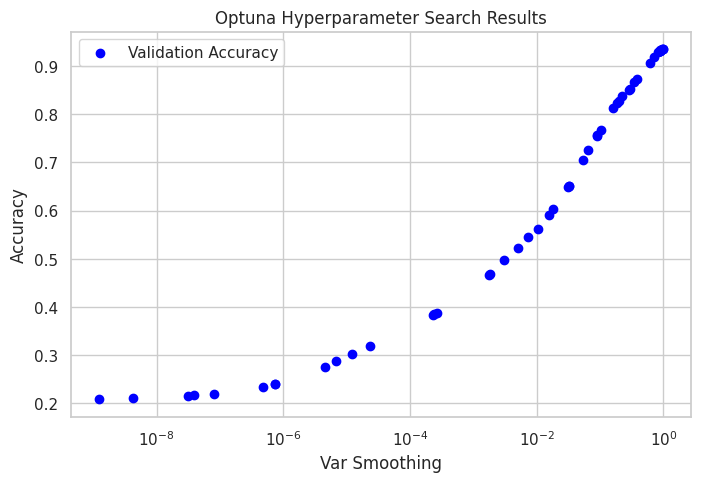

In [64]:
# 6. Plotting search results
# Manually collect trials
study = optuna_search.study_
trial_params = [trial.params['var_smoothing'] for trial in study.trials]
trial_scores = [trial.value for trial in study.trials]

plt.figure(figsize=(8, 5))
plt.scatter(trial_params, trial_scores, color='blue', label='Validation Accuracy')
plt.xscale('log')
plt.xlabel('Var Smoothing')
plt.ylabel('Accuracy')
plt.title('Optuna Hyperparameter Search Results')
plt.legend()
plt.grid(True)
plt.show()

In [65]:
y_test_pred = optuna_search.predict(X_test)

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='weighted')
conf_matrix_test = confusion_matrix(y_test, y_test_pred)

print(f"\nTest Set Metrics:")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")


Test Set Metrics:
Precision: 0.92
Recall: 0.93
F1-Score: 0.93


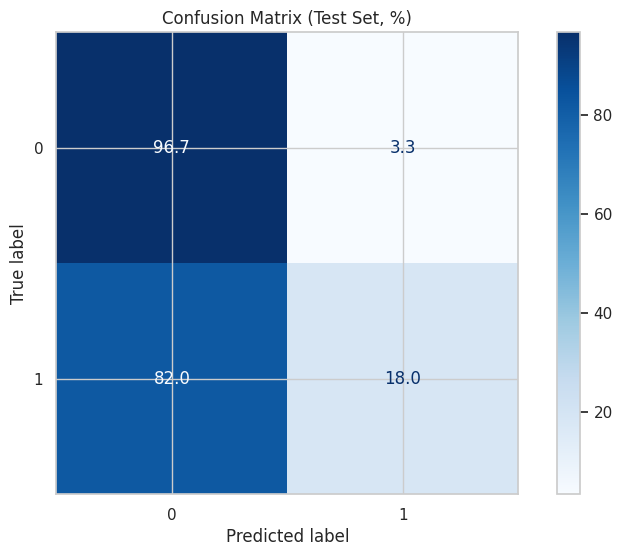

In [66]:
cm_percent = conf_matrix_test.astype('float') / conf_matrix_test.sum(axis=1)[:, np.newaxis] * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=optuna_search.classes_)
disp.plot(cmap='Blues', values_format=".1f")
plt.title("Confusion Matrix (Test Set, %)")
plt.show()

In [ ]:
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       972
           1       0.22      0.18      0.20        50

    accuracy                           0.93      1022
   macro avg       0.59      0.57      0.58      1022
weighted avg       0.92      0.93      0.93      1022



accracy is much better than base model but grid search is better overall

## SVM with hyper parameter tuning

### grid search

In [67]:
# --- 2. SVM Model ---
svm_model = SVC(probability=True, random_state=42)


In [68]:

# --- 3. GridSearchCV for SVM ---
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
}

In [69]:
grid_search_svm = GridSearchCV(svm_model, param_grid_svm, cv=5, scoring='accuracy', verbose=1)
grid_search_svm.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5, estimator=SVC(probability=True, random_state=42),
             param_grid={'C': [0.1, 1, 10], 'class_weight': ['balanced'],
                         'gamma': ['scale', 'auto'], 'kernel': ['rbf']},
             scoring='accuracy', verbose=1)

In [70]:
best_params_grid = grid_search_svm.best_params_
train_accuracy_grid = grid_search_svm.best_score_
val_accuracy_grid = grid_search_svm.score(X_val, y_val)

In [71]:
print("\n=== SVM GridSearch Results ===")
print(f"Best Parameters: {best_params_grid}")
print(f"Training Accuracy: {train_accuracy_grid:.2f}")
print(f"Validation Accuracy: {val_accuracy_grid:.2f}")


=== SVM GridSearch Results ===
Best Parameters: {'C': 10, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}
Training Accuracy: 0.83
Validation Accuracy: 0.84



Test Set Metrics (GridSearch):
Precision: 0.92
Recall: 0.84
F1-Score: 0.88


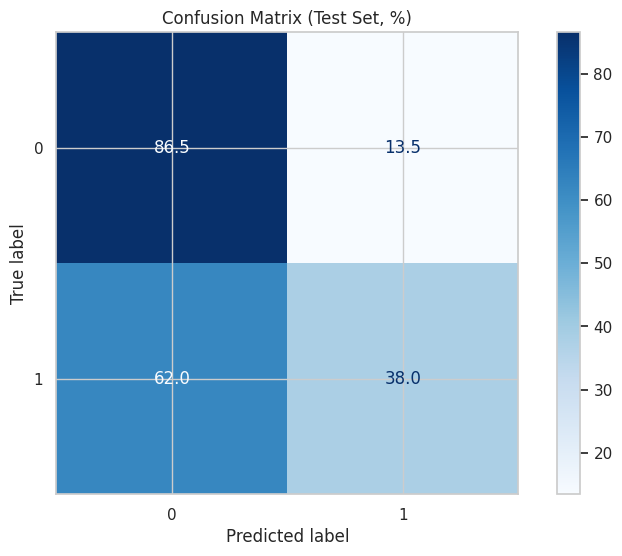


Classification Report (Test Set - GridSearch):
              precision    recall  f1-score   support

           0       0.96      0.87      0.91       972
           1       0.13      0.38      0.19        50

    accuracy                           0.84      1022
   macro avg       0.55      0.62      0.55      1022
weighted avg       0.92      0.84      0.88      1022



In [72]:
y_test_pred_grid = grid_search_svm.predict(X_test)

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred_grid, average='weighted')
conf_matrix_test = confusion_matrix(y_test, y_test_pred_grid)

print(f"\nTest Set Metrics (GridSearch):")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

cm_percent = conf_matrix_test.astype('float') / conf_matrix_test.sum(axis=1)[:, np.newaxis] * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=grid_search_svm.classes_)
disp.plot(cmap='Blues', values_format=".1f")  # Show percentages with 1 decimal
plt.title("Confusion Matrix (Test Set, %)")
plt.show()

print("\nClassification Report (Test Set - GridSearch):")
print(classification_report(y_test, y_test_pred_grid))

accuracy better than base model

### optuna search

In [73]:
optuna_search_svm = OptunaSearchCV(
    svm_model,
    {
        'C': optuna.distributions.FloatDistribution(1e-2, 1e2, log=True),
        'gamma': optuna.distributions.FloatDistribution(1e-4, 1e1, log=True),
        'kernel': optuna.distributions.CategoricalDistribution(['rbf', 'poly']),  # Changed to CategoricalDistribution
        'class_weight': optuna.distributions.CategoricalDistribution(['balanced'])  # Changed to CategoricalDistribution
    },
    n_trials=20,
    cv=2,
    scoring='accuracy',
    verbose=1,
    random_state=42
)

<ipython-input-73-ea66dce6470c>:1: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search_svm = OptunaSearchCV(


2 fold validation less reliable but for the sake of saving time

In [74]:
optuna_search_svm.fit(X_train, y_train)


[I 2025-04-28 03:07:19,509] A new study created in memory with name: no-name-34052880-5436-4060-b58a-9fbaff591173
INFO:optuna_integration.sklearn.sklearn:Searching the best hyperparameters using 3066 samples...
[I 2025-04-28 03:07:21,273] Trial 0 finished with value: 0.8659491193737769 and parameters: {'C': 0.6588767896869547, 'gamma': 1.4559959319972098, 'kernel': 'poly', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8659491193737769.
[I 2025-04-28 03:07:22,311] Trial 1 finished with value: 0.7067840834964123 and parameters: {'C': 0.872466523122434, 'gamma': 0.0030996178756476853, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8659491193737769.
[I 2025-04-28 03:07:23,310] Trial 2 finished with value: 0.49967384213959554 and parameters: {'C': 0.05068567405352181, 'gamma': 0.003914949966612523, 'kernel': 'poly', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8659491193737769.
[I 2025-04-28 03:07:24,343] Trial 3 finished with value: 0

OptunaSearchCV(cv=2, estimator=SVC(probability=True, random_state=42), n_jobs=1,
               n_trials=20,
               param_distributions={'C': FloatDistribution(high=100.0, log=True, low=0.01, step=None),
                                    'class_weight': CategoricalDistribution(choices=('balanced',)),
                                    'gamma': FloatDistribution(high=10.0, log=True, low=0.0001, step=None),
                                    'kernel': CategoricalDistribution(choices=('rbf', 'poly'))},
               random_state=42, scoring='accuracy', verbose=1)

In [75]:
best_params_optuna = optuna_search_svm.best_params_
train_accuracy_optuna = optuna_search_svm.best_score_
val_accuracy_optuna = optuna_search_svm.score(X_val, y_val)

In [76]:
print("\n=== SVM OptunaSearch Results ===")
print(f"Best Parameters: {best_params_optuna}")
print(f"Training Accuracy: {train_accuracy_optuna:.2f}")
print(f"Validation Accuracy: {val_accuracy_optuna:.2f}")


=== SVM OptunaSearch Results ===
Best Parameters: {'C': 16.045606049646423, 'gamma': 9.602122686012896, 'kernel': 'rbf', 'class_weight': 'balanced'}
Training Accuracy: 0.95
Validation Accuracy: 0.95



Test Set Metrics (OptunaSearch):
Precision: 0.91
Recall: 0.94
F1-Score: 0.92


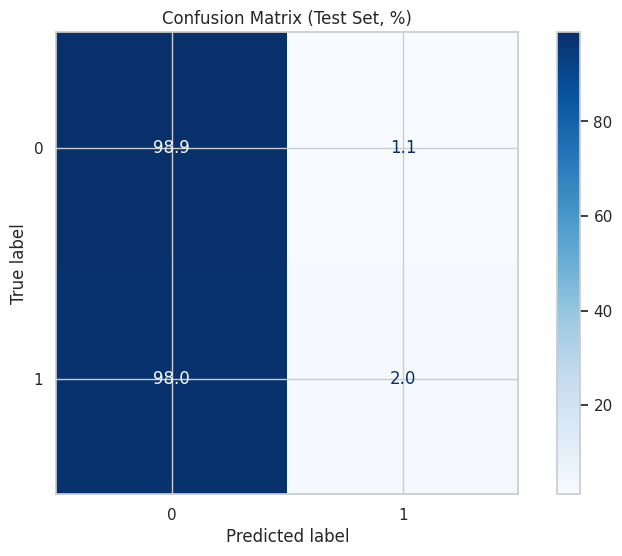


Classification Report (Test Set - OptunaSearch):
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       972
           1       0.08      0.02      0.03        50

    accuracy                           0.94      1022
   macro avg       0.52      0.50      0.50      1022
weighted avg       0.91      0.94      0.92      1022



In [77]:
y_test_pred_optuna = optuna_search_svm.predict(X_test)

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred_optuna, average='weighted')
conf_matrix_test_optuna = confusion_matrix(y_test, y_test_pred_optuna)

print(f"\nTest Set Metrics (OptunaSearch):")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

cm_percent = conf_matrix_test_optuna.astype('float') / conf_matrix_test_optuna.sum(axis=1)[:, np.newaxis] * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=optuna_search_svm.classes_)
disp.plot(cmap='Blues', values_format=".1f")
plt.title("Confusion Matrix (Test Set, %)")
plt.show()

print("\nClassification Report (Test Set - OptunaSearch):")
print(classification_report(y_test, y_test_pred_optuna))

accuracy better than base model and grid search

In [78]:
optuna.visualization.plot_optimization_history(optuna_search_svm.study_).show()


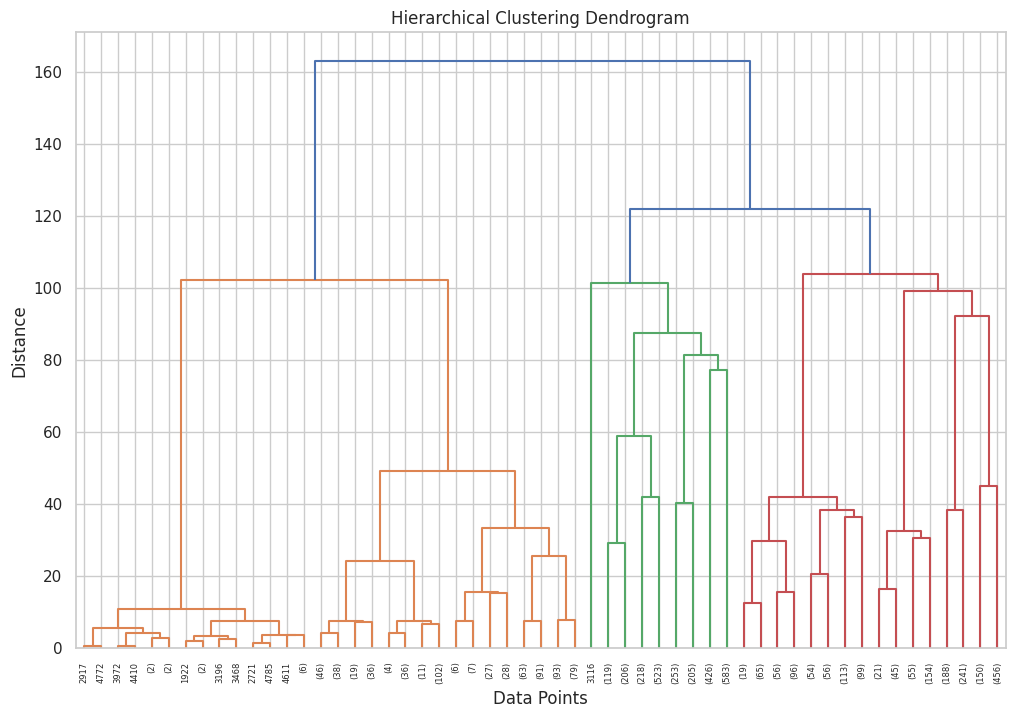

In [79]:
linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

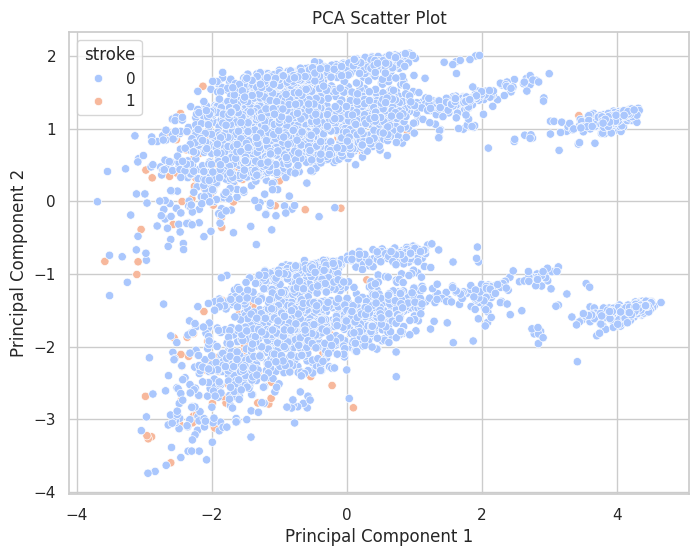

In [80]:
# --- 9. PCA Visualization ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='coolwarm')
plt.title("PCA Scatter Plot")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Feature reduction

Residence_type: Shows very low correlations with all other variables, indicating it likely has little to no impact on the target or other features.

gender_Female and gender_Male: These are perfectly correlated (1.000), which means they are redundant. Only one gender variable should be kept (e.g., "gender_Male" as a binary indicator, with "gender_Female" implied when "gender_Male" is 0).

gender_Other: Shows negligible correlations with all other variables, suggesting it may not be informative for the model.

work_type_Never_worked: Has very low correlations with other variables and might represent a very small subset of the data, making it less useful for generalization.

Consider removing ever_married or work_type_children if age is kept, due to their high correlation with age.

## encoding dataset

In [81]:
from sklearn.preprocessing import LabelEncoder

# Make sure you're working with the corrected dataframe
df_oh = df_clean.copy()

# Then redo the encoding
le = LabelEncoder()
df_oh['ever_married'] = le.fit_transform(df_oh['ever_married'])
df_oh['Residence_type'] = le.fit_transform(df_oh['Residence_type'])

# One-hot encoding
df_oh = pd.get_dummies(df_oh, columns=['gender', 'work_type', 'smoking_status'] , dtype=int)
# Verify
print(df_oh.columns)
df_oh.head()

Index(['age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'bmi', 'stroke', 'gender_Female',
       'gender_Male', 'gender_Other', 'work_type_Govt_job',
       'work_type_Never_worked', 'work_type_Private',
       'work_type_Self-employed', 'work_type_children',
       'smoking_status_Unknown', 'smoking_status_formerly smoked',
       'smoking_status_never smoked', 'smoking_status_smokes'],
      dtype='object')


,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,1,1,228.69,36.60,1,0,1,0,0,0,1,0,0,0,1,0,0
1,61.0,0,0,1,0,202.21,31.14,1,1,0,0,0,0,0,1,0,0,0,1,0
2,80.0,0,1,1,0,105.92,32.50,1,0,1,0,0,0,1,0,0,0,0,1,0
3,49.0,0,0,1,1,171.23,34.40,1,1,0,0,0,0,1,0,0,0,0,0,1
4,79.0,1,0,1,0,174.12,24.00,1,1,0,0,0,0,0,1,0,0,0,1,0


In [82]:
df_oh.drop(['Residence_type'], axis=1, inplace=True)

In [83]:
df_oh.drop(['gender_Other', 'gender_Female'], axis=1, inplace=True)

In [84]:
df_oh.drop(['work_type_Never_worked'], axis=1, inplace=True)

In [85]:
df_oh.drop(['work_type_children'], axis=1, inplace=True)

In [86]:
df_oh.drop(['ever_married'], axis=1, inplace=True)

In [87]:
df_oh.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,work_type_Govt_job,work_type_Private,work_type_Self-employed,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.60,1,1,0,1,0,0,1,0,0
1,61.0,0,0,202.21,31.14,1,0,0,0,1,0,0,1,0
2,80.0,0,1,105.92,32.50,1,1,0,1,0,0,0,1,0
3,49.0,0,0,171.23,34.40,1,0,0,1,0,0,0,0,1
4,79.0,1,0,174.12,24.00,1,0,0,0,1,0,0,1,0


# Models with no hyper parameter tuning

## Data splitting

In [60]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_oh.drop('stroke', axis=1)
y = df_oh['stroke']

# First, split off the test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

# Then, split the remaining into train (70%) and validation (15% of original total)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)  # 0.1765 * 85% ≈ 15%

# Show the size of each set
print(f"Train set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Also, show class distribution to ensure balance
print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))


Train set: 3576 samples
Validation set: 767 samples
Test set: 767 samples

Class distribution in training set:
stroke
0    0.951063
1    0.048937
Name: proportion, dtype: float64


## Naïve Bayes no hyper parameter tuning

=== Naïve Bayes Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.88      0.92       730
           1       0.13      0.35      0.19        37

    accuracy                           0.86       767
   macro avg       0.55      0.62      0.56       767
weighted avg       0.92      0.86      0.89       767



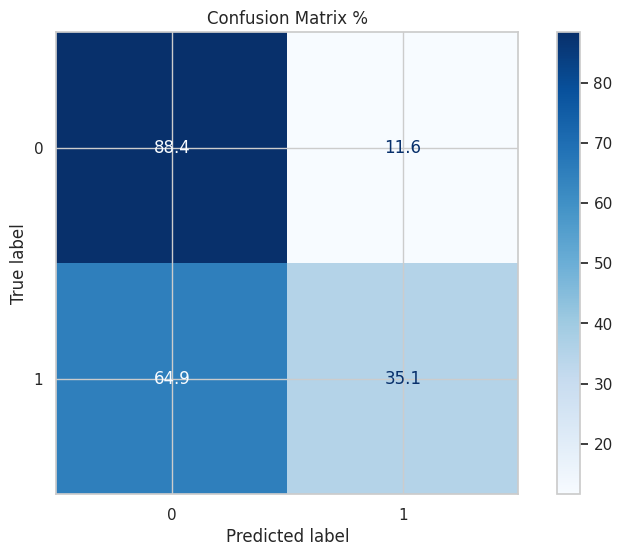

In [61]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train the model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predict on validation set
y_val_pred_nb = nb_model.predict(X_val)

# Evaluate
print("=== Naïve Bayes Classification Report ===")
print(classification_report(y_val, y_val_pred_nb))

# Confusion Matrix in percentage
cm_nb = confusion_matrix(y_val, y_val_pred_nb)
cm_nb_percentage = cm_nb.astype('float') / cm_nb.sum(axis=1)[:, np.newaxis] * 100  # Convert to percentage

disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb_percentage,
                                display_labels=nb_model.classes_)
disp_nb.plot(cmap='Blues', values_format='.1f')  # '.1f' formats to 1 decimal place
plt.title("Confusion Matrix %")
plt.show()

model accuracy greatly increased after feature reduction

## SVM no hyper parameter tuning

=== SVM Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.77      0.86       730
           1       0.12      0.62      0.20        37

    accuracy                           0.76       767
   macro avg       0.55      0.69      0.53       767
weighted avg       0.93      0.76      0.83       767



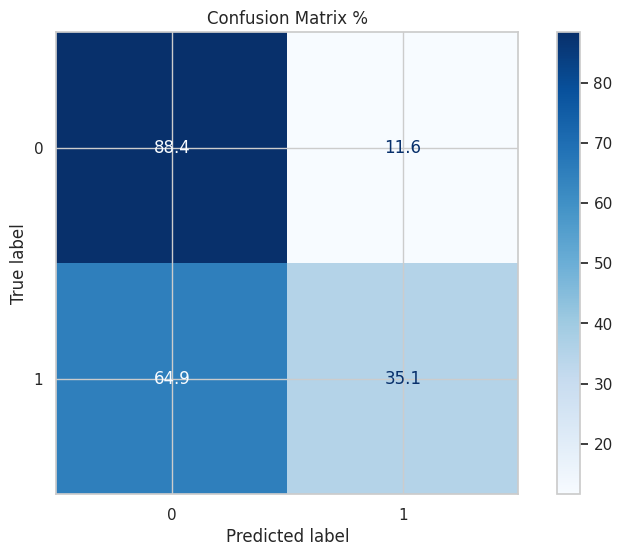

In [62]:
# Build the pipeline (scaling + SVM)
svm_pipeline = make_pipeline(StandardScaler(), SVC(kernel='rbf', class_weight='balanced', random_state=42))

# Train the model
svm_pipeline.fit(X_train, y_train)

# Predict on validation set
y_pred_svm = svm_pipeline.predict(X_val)

# Evaluate
print("=== SVM Classification Report ===")
print(classification_report(y_val, y_pred_svm))

# Confusion Matrix in percentage
cm_nb = confusion_matrix(y_val, y_val_pred_nb)
cm_nb_percentage = cm_nb.astype('float') / cm_nb.sum(axis=1)[:, np.newaxis] * 100  # Convert to percentage

disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb_percentage,
                                display_labels=nb_model.classes_)
disp_nb.plot(cmap='Blues', values_format='.1f')  # '.1f' formats to 1 decimal place
plt.title("Confusion Matrix %")
plt.show()


model benifited from feature reduction and accuracy increased by 0.01

# Models with hyper parameter tuning

In [88]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Set a consistent style for plots
sns.set_theme(style="whitegrid")


In [89]:

X = df_oh.drop('stroke', axis=1)
y = df_oh['stroke']


In [90]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [91]:
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
print(f"Training Set: {X_train.shape}, Validation Set: {X_val.shape}, Testing Set: {X_test.shape}")

Training Set: (3066, 13), Validation Set: (1022, 13), Testing Set: (1022, 13)


## Naïve Bayes with hyper parameter tuning

###  grid search

In [74]:
nb_model = GaussianNB()

# Define hyperparameter configurations
param_grid = {
    'var_smoothing': np.logspace(-9, 0, 50)  # Example parameter grid
}

# Perform grid search for hyperparameter tuning
grid_search = GridSearchCV(nb_model, param_grid, cv=5, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


GridSearchCV(cv=5, estimator=GaussianNB(),
             param_grid={'var_smoothing': array([1.00000000e-09, 1.52641797e-09, 2.32995181e-09, 3.55648031e-09,
       5.42867544e-09, 8.28642773e-09, 1.26485522e-08, 1.93069773e-08,
       2.94705170e-08, 4.49843267e-08, 6.86648845e-08, 1.04811313e-07,
       1.59985872e-07, 2.44205309e-07, 3.72759372e-07, 5.68986603e-07,
       8.68511374e-07, 1.32571137e-06, 2.02...
       1.38949549e-04, 2.12095089e-04, 3.23745754e-04, 4.94171336e-04,
       7.54312006e-04, 1.15139540e-03, 1.75751062e-03, 2.68269580e-03,
       4.09491506e-03, 6.25055193e-03, 9.54095476e-03, 1.45634848e-02,
       2.22299648e-02, 3.39322177e-02, 5.17947468e-02, 7.90604321e-02,
       1.20679264e-01, 1.84206997e-01, 2.81176870e-01, 4.29193426e-01,
       6.55128557e-01, 1.00000000e+00])},
             scoring='accuracy', verbose=1)

In [75]:
best_params = grid_search.best_params_
train_accuracy = grid_search.best_score_
val_accuracy = grid_search.score(X_val, y_val)

In [76]:
print(f"Best Parameters: {best_params}")
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Validation Accuracy: {val_accuracy:.2f}")

Best Parameters: {'var_smoothing': np.float64(1.0)}
Training Accuracy: 0.93
Validation Accuracy: 0.94


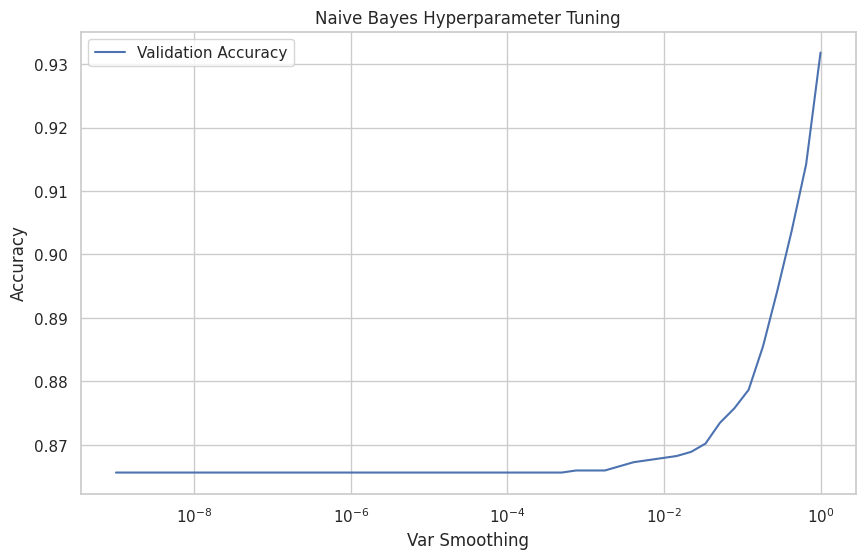

In [77]:
results = pd.DataFrame(grid_search.cv_results_)
plt.plot(results['param_var_smoothing'], results['mean_test_score'], label="Validation Accuracy")
plt.xscale('log')
plt.xlabel('Var Smoothing')
plt.ylabel('Accuracy')
plt.title('Naive Bayes Hyperparameter Tuning')
plt.legend()
plt.show()

In [78]:

y_test_pred = grid_search.predict(X_test)

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='weighted')
conf_matrix_test = confusion_matrix(y_test, y_test_pred)

In [79]:
print(f"Test Set Metrics:")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Test Set Metrics:
Precision: 0.92
Recall: 0.93
F1-Score: 0.93


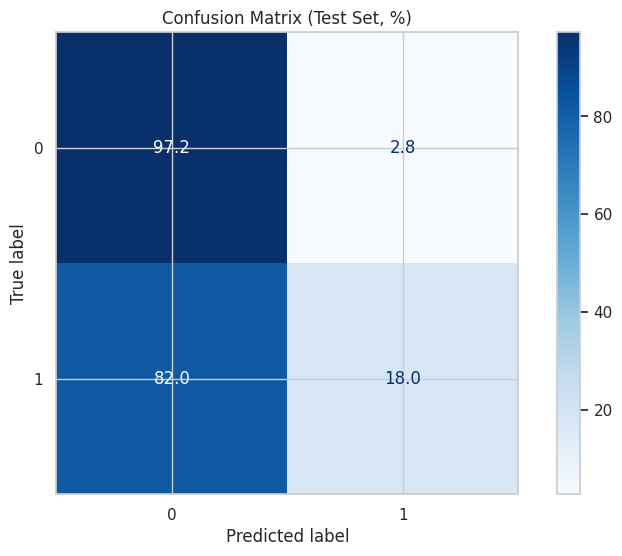

In [80]:
cm_percent = conf_matrix_test.astype('float') / conf_matrix_test.sum(axis=1)[:, np.newaxis] * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=grid_search.classes_)
disp.plot(cmap='Blues', values_format=".1f")  # Show percentages with 1 decimal
plt.title("Confusion Matrix (Test Set, %)")
plt.show()

In [81]:
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       972
           1       0.25      0.18      0.21        50

    accuracy                           0.93      1022
   macro avg       0.60      0.58      0.59      1022
weighted avg       0.92      0.93      0.93      1022



model did not benifit from feature reduction and accuracy remained the same

In [ ]:
linkage_matrix = linkage(X_scaled, method='ward')

### optuna search

In [ ]:
!pip install optuna

In [ ]:
!pip install optuna-integration[sklearn]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 kB 2.5 MB/s eta 0:00:00


In [82]:
# 3. Define Model
nb_model = GaussianNB()

# 4. Optuna Search
param_distributions = {
    'var_smoothing': FloatDistribution(1e-9, 1e0, log=True)  # Using FloatDistribution with log=True
}

In [83]:
optuna_search = OptunaSearchCV(
    nb_model,
    param_distributions,
    cv=5,
    n_trials=50,        # Number of trials (searches) to do
    random_state=42,
    scoring='accuracy',
    verbose=1,
    refit=True
)

<ipython-input-83-d9eaa06e4f3f>:1: ExperimentalWarning:

OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.



In [84]:
optuna_search.fit(X_train, y_train)


[I 2025-04-28 02:44:31,723] A new study created in memory with name: no-name-69ebcba7-5129-4c90-9979-b1ddc2132956
INFO:optuna_integration.sklearn.sklearn:Searching the best hyperparameters using 3066 samples...
[I 2025-04-28 02:44:31,753] Trial 0 finished with value: 0.8656248173398303 and parameters: {'var_smoothing': 1.2368284599556906e-05}. Best is trial 0 with value: 0.8656248173398303.
[I 2025-04-28 02:44:31,777] Trial 1 finished with value: 0.8695378631284175 and parameters: {'var_smoothing': 0.031166518451724804}. Best is trial 1 with value: 0.8695378631284175.
[I 2025-04-28 02:44:31,799] Trial 2 finished with value: 0.8656248173398303 and parameters: {'var_smoothing': 4.182751540781787e-09}. Best is trial 1 with value: 0.8695378631284175.
[I 2025-04-28 02:44:31,821] Trial 3 finished with value: 0.8656248173398303 and parameters: {'var_smoothing': 7.499378258136028e-07}. Best is trial 1 with value: 0.8695378631284175.
[I 2025-04-28 02:44:31,845] Trial 4 finished with value: 0.86

OptunaSearchCV(cv=5, estimator=GaussianNB(), n_jobs=1, n_trials=50,
               param_distributions={'var_smoothing': FloatDistribution(high=1.0, log=True, low=1e-09, step=None)},
               random_state=42, scoring='accuracy', verbose=1)

In [85]:
# 5. Best params and scores
best_params = optuna_search.best_params_
train_accuracy = optuna_search.best_score_
val_accuracy = optuna_search.score(X_val, y_val)

In [86]:
print(f"\nBest Parameters: {best_params}")
print(f"Training Accuracy (CV avg): {train_accuracy:.2f}")
print(f"Validation Accuracy: {val_accuracy:.2f}")



Best Parameters: {'var_smoothing': 0.9775959511531825}
Training Accuracy (CV avg): 0.93
Validation Accuracy: 0.94


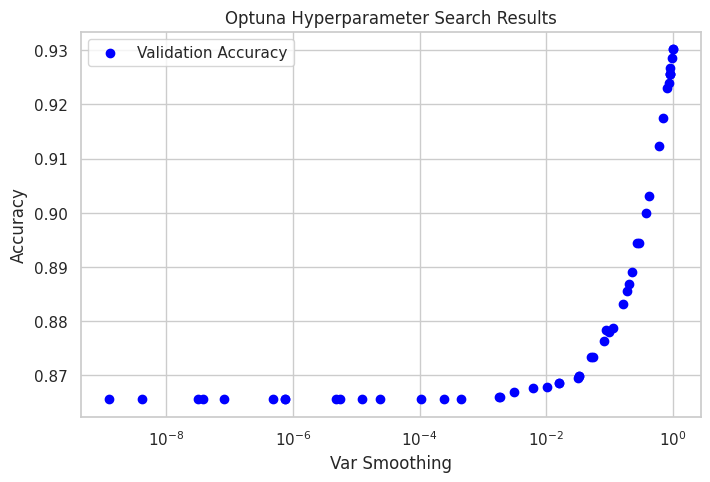

In [87]:
# 6. Plotting search results
# Manually collect trials
study = optuna_search.study_
trial_params = [trial.params['var_smoothing'] for trial in study.trials]
trial_scores = [trial.value for trial in study.trials]

plt.figure(figsize=(8, 5))
plt.scatter(trial_params, trial_scores, color='blue', label='Validation Accuracy')
plt.xscale('log')
plt.xlabel('Var Smoothing')
plt.ylabel('Accuracy')
plt.title('Optuna Hyperparameter Search Results')
plt.legend()
plt.grid(True)
plt.show()

In [88]:
y_test_pred = optuna_search.predict(X_test)

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='weighted')
conf_matrix_test = confusion_matrix(y_test, y_test_pred)

print(f"\nTest Set Metrics:")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")


Test Set Metrics:
Precision: 0.92
Recall: 0.93
F1-Score: 0.93


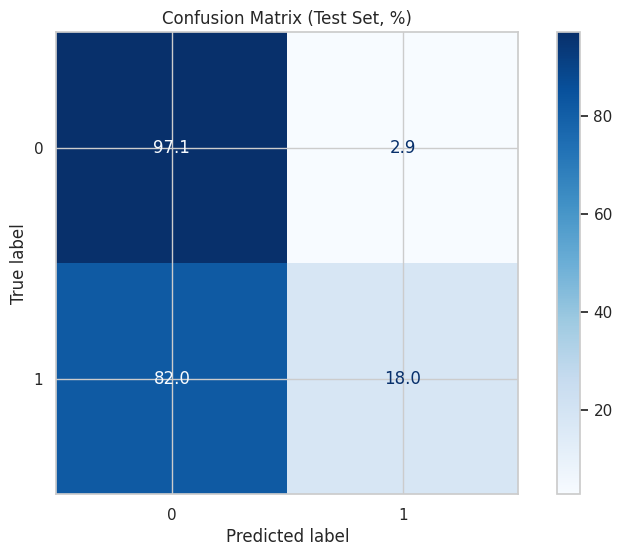

In [89]:
cm_percent = conf_matrix_test.astype('float') / conf_matrix_test.sum(axis=1)[:, np.newaxis] * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=optuna_search.classes_)
disp.plot(cmap='Blues', values_format=".1f")
plt.title("Confusion Matrix (Test Set, %)")
plt.show()

In [90]:
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       972
           1       0.24      0.18      0.21        50

    accuracy                           0.93      1022
   macro avg       0.60      0.58      0.59      1022
weighted avg       0.92      0.93      0.93      1022



madel benifited from feature reduction but accuracy remained the same

## SVM with hyper parameter tuning

### grid search

In [91]:
# --- 2. SVM Model ---
svm_model = SVC(probability=True, random_state=42)


In [92]:

# --- 3. GridSearchCV for SVM ---
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
}

less reliable grid search but for the sake of saving time

In [93]:
grid_search_svm = GridSearchCV(svm_model, param_grid_svm, cv=5, scoring='accuracy', verbose=1)
grid_search_svm.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5, estimator=SVC(probability=True, random_state=42),
             param_grid={'C': [0.1, 1, 10], 'class_weight': ['balanced'],
                         'gamma': ['scale', 'auto'], 'kernel': ['rbf']},
             scoring='accuracy', verbose=1)

In [94]:
best_params_grid = grid_search_svm.best_params_
train_accuracy_grid = grid_search_svm.best_score_
val_accuracy_grid = grid_search_svm.score(X_val, y_val)

In [95]:
print("\n=== SVM GridSearch Results ===")
print(f"Best Parameters: {best_params_grid}")
print(f"Training Accuracy: {train_accuracy_grid:.2f}")
print(f"Validation Accuracy: {val_accuracy_grid:.2f}")


=== SVM GridSearch Results ===
Best Parameters: {'C': 10, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
Training Accuracy: 0.81
Validation Accuracy: 0.81



Test Set Metrics (GridSearch):
Precision: 0.93
Recall: 0.82
F1-Score: 0.86


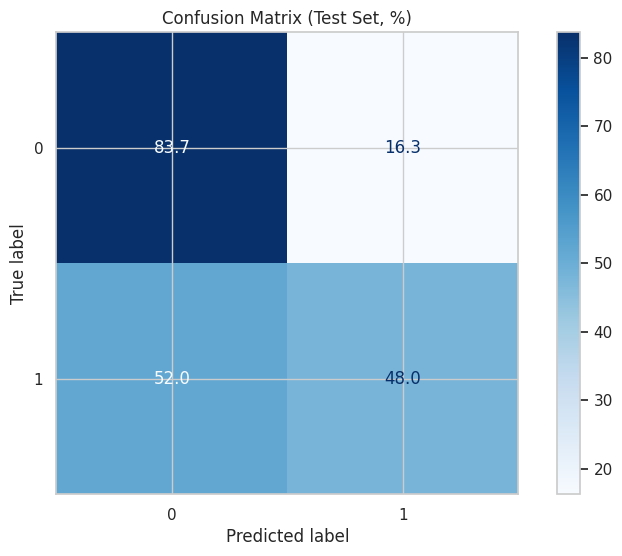


Classification Report (Test Set - GridSearch):
              precision    recall  f1-score   support

           0       0.97      0.84      0.90       972
           1       0.13      0.48      0.21        50

    accuracy                           0.82      1022
   macro avg       0.55      0.66      0.55      1022
weighted avg       0.93      0.82      0.86      1022



In [96]:
y_test_pred_grid = grid_search_svm.predict(X_test)

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred_grid, average='weighted')
conf_matrix_test = confusion_matrix(y_test, y_test_pred_grid)

print(f"\nTest Set Metrics (GridSearch):")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

cm_percent = conf_matrix_test.astype('float') / conf_matrix_test.sum(axis=1)[:, np.newaxis] * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=grid_search_svm.classes_)
disp.plot(cmap='Blues', values_format=".1f")  # Show percentages with 1 decimal
plt.title("Confusion Matrix (Test Set, %)")
plt.show()

print("\nClassification Report (Test Set - GridSearch):")
print(classification_report(y_test, y_test_pred_grid))

model did not benifit from feature reduction and accuracy decreased by 0.02

accuracy better than base model

### optuna search

In [15]:
optuna_search_svm = OptunaSearchCV(
    svm_model,
    {
        'C': optuna.distributions.FloatDistribution(1e-2, 1e2, log=True),
        'gamma': optuna.distributions.FloatDistribution(1e-4, 1e1, log=True),
        'kernel': optuna.distributions.CategoricalDistribution(['rbf', 'poly']),  # Changed to CategoricalDistribution
        'class_weight': optuna.distributions.CategoricalDistribution(['balanced'])  # Changed to CategoricalDistribution
    },
    n_trials=4,
    cv=2,
    scoring='accuracy',
    verbose=1,
    random_state=42
)

<ipython-input-15-9f0ff062fd4d>:1: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search_svm = OptunaSearchCV(


for some unknown reason optuna is stuck on the 4th iteration therfore number of n_trials is 4

In [21]:
optuna_search_svm.fit(X_train, y_train)


[I 2025-04-28 02:56:30,580] A new study created in memory with name: no-name-0c5bb987-5641-4d5b-832c-911608173e23
INFO:optuna_integration.sklearn.sklearn:Searching the best hyperparameters using 3066 samples...
[I 2025-04-28 02:56:38,474] Trial 0 finished with value: 0.8558382257012394 and parameters: {'C': 0.6588767896869547, 'gamma': 1.4559959319972098, 'kernel': 'poly', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8558382257012394.
[I 2025-04-28 02:56:39,510] Trial 1 finished with value: 0.7022178734507502 and parameters: {'C': 0.872466523122434, 'gamma': 0.0030996178756476853, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8558382257012394.
[I 2025-04-28 02:56:40,595] Trial 2 finished with value: 0.49967384213959554 and parameters: {'C': 0.05068567405352181, 'gamma': 0.003914949966612523, 'kernel': 'poly', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8558382257012394.
[I 2025-04-28 02:56:41,685] Trial 3 finished with value: 0

OptunaSearchCV(cv=2, estimator=SVC(probability=True, random_state=42), n_jobs=1,
               n_trials=4,
               param_distributions={'C': FloatDistribution(high=100.0, log=True, low=0.01, step=None),
                                    'class_weight': CategoricalDistribution(choices=('balanced',)),
                                    'gamma': FloatDistribution(high=10.0, log=True, low=0.0001, step=None),
                                    'kernel': CategoricalDistribution(choices=('rbf', 'poly'))},
               random_state=42, scoring='accuracy', verbose=1)

In [22]:
best_params_optuna = optuna_search_svm.best_params_
train_accuracy_optuna = optuna_search_svm.best_score_
val_accuracy_optuna = optuna_search_svm.score(X_val, y_val)

In [23]:
print("\n=== SVM OptunaSearch Results ===")
print(f"Best Parameters: {best_params_optuna}")
print(f"Training Accuracy: {train_accuracy_optuna:.2f}")
print(f"Validation Accuracy: {val_accuracy_optuna:.2f}")


=== SVM OptunaSearch Results ===
Best Parameters: {'C': 0.6588767896869547, 'gamma': 1.4559959319972098, 'kernel': 'poly', 'class_weight': 'balanced'}
Training Accuracy: 0.86
Validation Accuracy: 0.81



Test Set Metrics (OptunaSearch):
Precision: 0.92
Recall: 0.82
F1-Score: 0.86


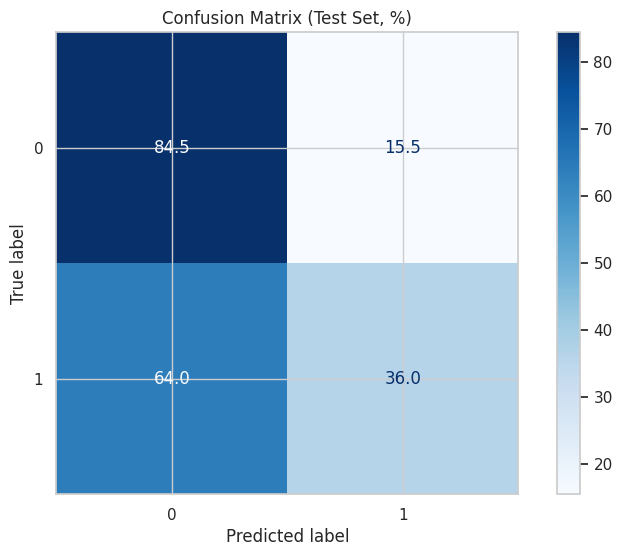


Classification Report (Test Set - OptunaSearch):
              precision    recall  f1-score   support

           0       0.96      0.84      0.90       972
           1       0.11      0.36      0.16        50

    accuracy                           0.82      1022
   macro avg       0.53      0.60      0.53      1022
weighted avg       0.92      0.82      0.86      1022



In [27]:
y_test_pred_optuna = optuna_search_svm.predict(X_test)

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred_optuna, average='weighted')
conf_matrix_test_optuna = confusion_matrix(y_test, y_test_pred_optuna)

print(f"\nTest Set Metrics (OptunaSearch):")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

cm_percent = conf_matrix_test_optuna.astype('float') / conf_matrix_test_optuna.sum(axis=1)[:, np.newaxis] * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=optuna_search_svm.classes_)
disp.plot(cmap='Blues', values_format=".1f")
plt.title("Confusion Matrix (Test Set, %)")
plt.show()

print("\nClassification Report (Test Set - OptunaSearch):")
print(classification_report(y_test, y_test_pred_optuna))

model was compromised by the feature reduction and accuracy was decraesd by 1.2

In [92]:
optuna.visualization.plot_optimization_history(optuna_search_svm.study_).show()


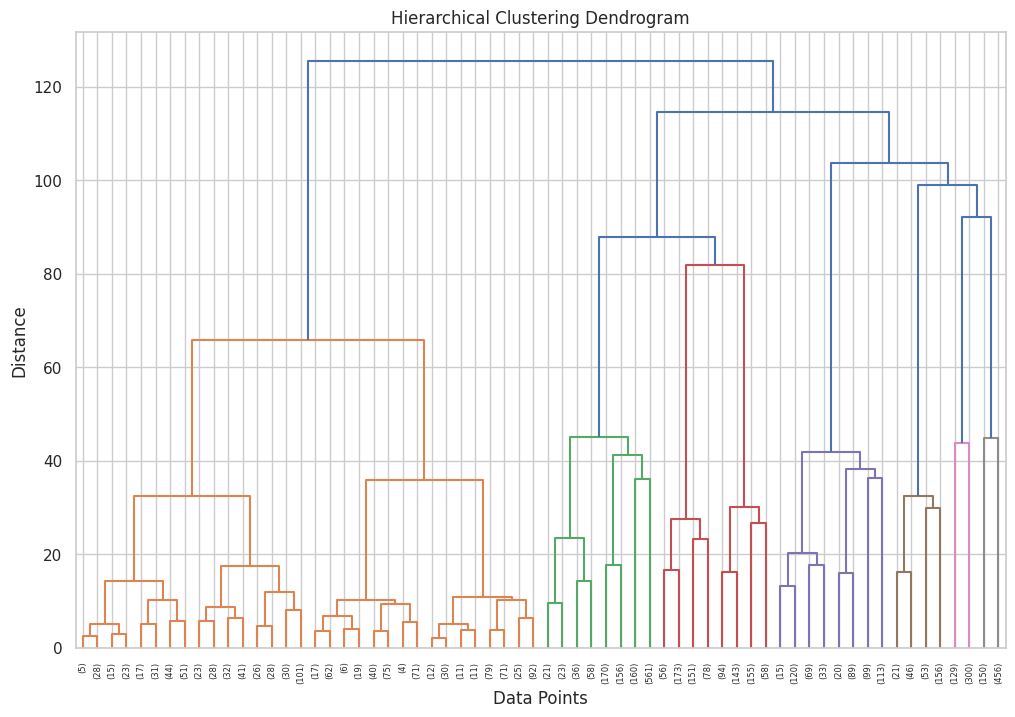

In [93]:
linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

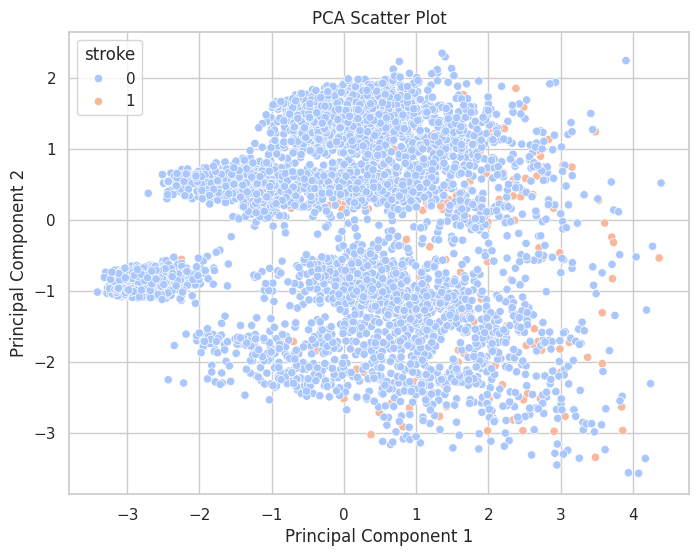

In [94]:
# --- 9. PCA Visualization ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='coolwarm')
plt.title("PCA Scatter Plot")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()